# 1. Project Introduction

**Project title:** Evaluating Hybrid Retrieval and Reranking for Retrieval-Augmented Biomedical Question Answering

**Research aim:** To evaluate whether hybrid retrieval with reranking improves retrieval accuracy and answer faithfulness in a biomedical RAG system, using PubMedQA and a fixed Gemini generator.

**Research question:** Does hybrid sparse and dense retrieval with reranking improve retrieval accuracy and answer faithfulness in biomedical question answering, compared with BM25-only and dense-only retrieval? A supporting question is whether improvements in retrieval quality are observable in answer-level performance.

**Design.** Retrieval is the only independent variable. The generator, the prompt, the decoding
settings and the question set are identical across every system, so a difference in answers can
be attributed to the evidence supplied rather than to how it was used. Four retrieval systems are
compared, in the order the proposal specifies.

| System | Retrieval | Objective |
|---|---|---|
| `bm25` | Sparse lexical retrieval | 2 — baseline |
| `dense` | Sentence embeddings in a FAISS index | 2 — baseline |
| `hybrid` | Sparse and dense results fused | 3 — improved |
| `hybrid_rerank` | Best hybrid configuration, reordered by a cross-encoder | 3 — improved |

A closed-book control answers the same questions with no retrieved evidence at all, which is what
distinguishes "retrieval helped" from "the model already knew the answer".

# 2. Import Libraries

## 2.0 Runtime Setup

This notebook runs unchanged on a local machine or on Google Colab. The cell below detects which, and on Colab it does three things that would otherwise catch the user out: it confirms whether a GPU is attached, it redirects output to Google Drive so nothing is lost when the session ends, and it copies the API key out of Colab Secrets into the environment, since secrets are not exposed as environment variables automatically.

In [1]:
# Detect the runtime and prepare it. A no-op outside Colab.
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
BASE_DIR = Path.cwd()

if IN_COLAB:
    # 1. Persist results. /content is cleared when the session ends, which would discard the
    #    embeddings, the response cache and every generated answer.
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        BASE_DIR = Path("/content/drive/MyDrive/biomedical_rag")
        BASE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Output directory: {BASE_DIR}")
    except Exception as error:
        print(f"Drive not mounted ({type(error).__name__}). Results will be lost when the "
              f"session ends; mount Drive before a long run.")

    # 2. Move the API key from Colab Secrets into the environment. Without this the notebook
    #    falls back to its offline generator and reports answer results that mean nothing.
    if not os.getenv("GOOGLE_API_KEY"):
        try:
            from google.colab import userdata
            os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
            print("API key loaded from Colab Secrets.")
        except Exception:
            print("No API key found. Add GOOGLE_API_KEY under the key icon in the sidebar, "
                  "or the notebook will use its offline generator.")

    # 3. Report the accelerator. On a CPU runtime the embedding stage takes roughly an hour and
    #    a half; on a GPU it takes a couple of minutes.
    try:
        import torch
        if torch.cuda.is_available():
            print(f"GPU: {torch.cuda.get_device_name(0)}")
        else:
            print("No GPU attached. Runtime > Change runtime type > T4 GPU is strongly "
                  "advised before running the embedding stage.")
    except ImportError:
        pass
else:
    print("Running locally.")


Running locally.


In [2]:
# Install only packages that are missing from the current runtime.
import importlib.util
import subprocess
import sys

required_packages = {
    "sentence_transformers": "sentence-transformers",
    "faiss": "faiss-cpu",
    "bm25s": "bm25s",
    "Stemmer": "PyStemmer",
    "datasets": "datasets",
    "google.genai": "google-genai",
}
for module, package in required_packages.items():
    if importlib.util.find_spec(module.split(".")[0]) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Standard library.
import hashlib
import json
import os
import re
import time
import unicodedata
import warnings
from collections import Counter, defaultdict
from pathlib import Path

# Third party.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
# Times New Roman is absent on most Linux runtimes; matplotlib falls back silently.
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight"})
pd.set_option("display.max_colwidth", 90)

# One colour per system, reused by every figure so a reader can follow one system throughout.
SYSTEM_LABELS = {
    "closed_book": "Closed-book", "bm25": "BM25-only", "dense": "Dense-only",
    "hybrid": "Hybrid", "hybrid_rerank": "Hybrid + rerank", "oracle": "Oracle",
}
SYSTEM_COLOURS = {
    "closed_book": "#8C8C8C", "bm25": "#4C72B0", "dense": "#DD8452",
    "hybrid": "#55A868", "hybrid_rerank": "#0C6357", "oracle": "#C44E52",
}
RETRIEVAL_SYSTEMS = ["bm25", "dense", "hybrid", "hybrid_rerank"]
ALL_SYSTEMS = ["closed_book"] + RETRIEVAL_SYSTEMS + ["oracle"]

OUTPUT_DIR = BASE_DIR / "outputs"     # BASE_DIR is Drive on Colab, cwd locally
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    # Every figure is written to outputs/ so it can be placed directly in the dissertation.
    for ext in ("png", "pdf"):
        fig.savefig(OUTPUT_DIR / f"{name}.{ext}")
    return fig


print("Libraries ready.")

Libraries ready.


# 3. Dataset Import and Inspection

## 3.1 Download and Load PubMedQA

In [3]:
# Download and load the PubMedQA expert-labelled subset and its unlabelled companion split.
from datasets import load_dataset

DATASET_ID = "qiaojin/PubMedQA"
labelled = load_dataset(DATASET_ID, "pqa_labeled")["train"]
unlabelled = load_dataset(DATASET_ID, "pqa_unlabeled")["train"]

print(f"pqa_labeled   : {len(labelled):,} expert-annotated instances (the evaluation set)")
print(f"pqa_unlabeled : {len(unlabelled):,} abstracts (retrieval distractors only)")

pqa_labeled   : 1,000 expert-annotated instances (the evaluation set)
pqa_unlabeled : 61,249 abstracts (retrieval distractors only)


## 3.2 Dataset Structure and Head

In [4]:
# Summarise the dataset structure, then show the field that decides the study's validity.
print("Fields in pqa_labeled:")
for name, spec in labelled.features.items():
    print(f"  {name:<16} {spec}")

display(Markdown(
    "**`context.contexts` is the abstract with its conclusion removed. `long_answer` *is* that "
    "conclusion**, and `final_decision` is the label derived from it. Both are answer keys. If "
    "either reached the retrieval corpus or the prompt, every accuracy and faithfulness figure "
    "below would be meaningless while the results looked excellent. §5.3 builds the guard that "
    "prevents it."
))

Fields in pqa_labeled:
  pubid            Value('int32')
  question         Value('string')
  context          {'contexts': List(Value('string')), 'labels': List(Value('string')), 'meshes': List(Value('string')), 'reasoning_required_pred': List(Value('string')), 'reasoning_free_pred': List(Value('string'))}
  long_answer      Value('string')
  final_decision   Value('string')


**`context.contexts` is the abstract with its conclusion removed. `long_answer` *is* that conclusion**, and `final_decision` is the label derived from it. Both are answer keys. If either reached the retrieval corpus or the prompt, every accuracy and faithfulness figure below would be meaningless while the results looked excellent. §5.3 builds the guard that prevents it.

## 3.3 One Complete Dataset Example

In [5]:
# Select one record and present its main fields clearly.
example = labelled[0]
print(f"pubid          : {example['pubid']}")
print(f"question       : {example['question']}")
print(f"final_decision : {example['final_decision']}   <-- label, never shown to the generator")
print()
print("context.contexts (the retrievable evidence):")
for label, segment in zip(example["context"]["labels"], example["context"]["contexts"]):
    print(f"  [{label}] {segment[:170]}{'...' if len(segment) > 170 else ''}")
print()
print("long_answer (the conclusion - an answer key, excluded from corpus and prompt):")
print(f"  {example['long_answer']}")

pubid          : 21645374
question       : Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
final_decision : yes   <-- label, never shown to the generator

context.contexts (the retrievable evidence):
  [BACKGROUND] Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through P...
  [RESULTS] The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window sta...

long_answer (the conclusion - an answer key, excluded from corpus and prompt):
  Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best of our knowledge, this is the first report of mitochondria and chloroplasts moving on transvacuolar str

# 4. Exploratory Data Analysis

## 4.1 Dataset Overview and Data Quality

In [6]:
# Create one tidy frame, then run the checks that would invalidate later results if they failed.
def to_frame(dataset, labelled=True):
    rows = []
    for record in dataset:
        context = record["context"]
        rows.append({
            "pubid": int(record["pubid"]),
            "question": record["question"],
            "abstract": " ".join(context["contexts"]),
            "n_segments": len(context["contexts"]),
            "long_answer": record.get("long_answer", ""),
            "label": record.get("final_decision", "") if labelled else "",
        })
    return pd.DataFrame(rows)


data = to_frame(labelled)

quality = pd.DataFrame({
    "Check": ["Duplicate pubid", "Empty question", "Empty abstract",
              "Empty conclusion", "Label outside {yes, no, maybe}"],
    "Count": [int(data["pubid"].duplicated().sum()),
              int((data["question"].str.strip() == "").sum()),
              int((data["abstract"].str.strip() == "").sum()),
              int((data["long_answer"].str.strip() == "").sum()),
              int((~data["label"].isin(["yes", "no", "maybe"])).sum())],
})
quality["Status"] = np.where(quality["Count"] == 0, "Clean", "Attention")
display(quality.style.hide(axis="index"))

Check,Count,Status
Duplicate pubid,0,Clean
Empty question,0,Clean
Empty abstract,0,Clean
Empty conclusion,0,Clean
"Label outside {yes, no, maybe}",0,Clean


## 4.2 Answer-Label Distribution

The class balance is the reason macro-F1 is reported beside accuracy rather than instead of it.
A system that never predicts the minority class can still post a respectable accuracy, and only
the per-class figures reveal it.

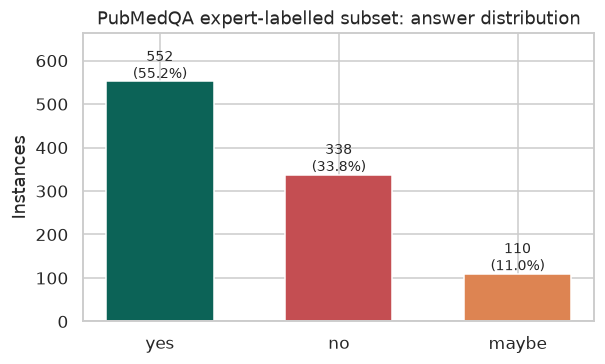

Always predicting **yes** would score 55.2% accuracy while scoring zero on the other two classes. The minority class **maybe** is only 11.0% of the data, so §7.3 reports macro-F1 and per-class F1 alongside accuracy.

In [7]:
# Plot the label distribution with count and percentage labels.
counts = data["label"].value_counts().reindex(["yes", "no", "maybe"]).fillna(0)
priors = counts / counts.sum()

fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(counts.index, counts.values, color=["#0C6357", "#C44E52", "#DD8452"], width=0.6)
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 8,
            f"{int(value):,}\n({value / counts.sum():.1%})", ha="center", fontsize=9)
ax.set(title="PubMedQA expert-labelled subset: answer distribution",
       ylabel="Instances", ylim=(0, counts.max() * 1.2))
save_fig(fig, "fig_01_label_distribution")
plt.show()

MAJORITY_ACCURACY = float(priors.max())
display(Markdown(
    f"Always predicting **{counts.idxmax()}** would score {MAJORITY_ACCURACY:.1%} accuracy while "
    f"scoring zero on the other two classes. The minority class **maybe** is only "
    f"{priors.get('maybe', 0):.1%} of the data, so §7.3 reports macro-F1 and per-class F1 "
    f"alongside accuracy."
))

## 4.3 Question, Abstract and Conclusion Lengths

Lengths drive three later choices: how many sentences make a sensible chunk, whether a
question-passage pair fits inside the cross-encoder window, and how many passages fit in the
prompt before the evidence begins competing with itself.

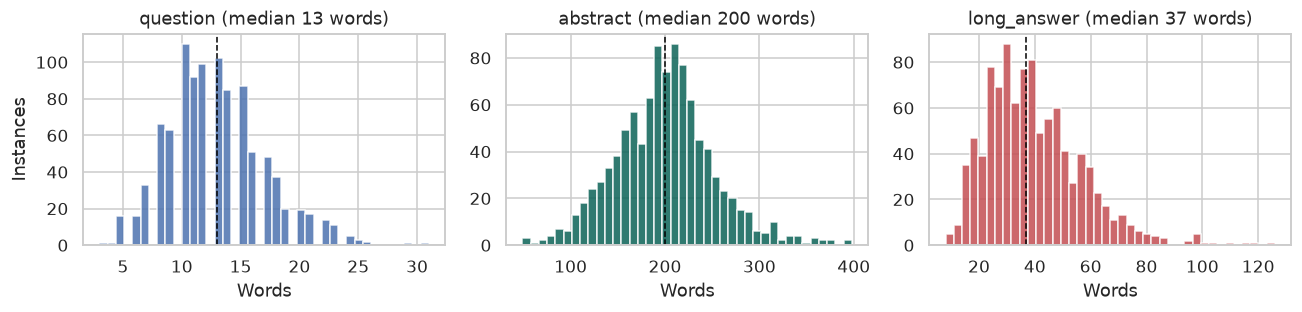

,count,mean,std,min,25%,50%,75%,max
question_words,1000.0,12.9,4.1,3.0,10.0,13.0,15.0,31.0
abstract_words,1000.0,200.2,51.8,49.0,166.8,200.5,228.0,398.0
long_answer_words,1000.0,39.7,17.2,8.0,27.0,37.0,49.0,126.0
n_segments,1000.0,3.4,1.1,1.0,3.0,3.0,3.0,9.0


In [8]:
# Calculate simple word counts while preserving the original text.
for column in ("question", "abstract", "long_answer"):
    data[f"{column}_words"] = data[column].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, column, colour in zip(axes, ("question", "abstract", "long_answer"),
                              ("#4C72B0", "#0C6357", "#C44E52")):
    values = data[f"{column}_words"]
    ax.hist(values, bins=40, color=colour, alpha=0.85)
    ax.axvline(values.median(), color="black", ls="--", lw=1)
    ax.set(title=f"{column} (median {values.median():.0f} words)", xlabel="Words")
axes[0].set_ylabel("Instances")
plt.tight_layout()
save_fig(fig, "fig_02_length_distributions")
plt.show()

display(data[["question_words", "abstract_words", "long_answer_words",
              "n_segments"]].describe().round(1).T)

## 4.4 How Much Does a Question Reveal About Its Own Abstract?

PubMedQA questions are derived from the titles of the articles they are paired with, so this is
**known-item retrieval** rather than open biomedical search. The measurement below quantifies the
advantage that gives a purely lexical retriever, and it is the reason §5.3 builds the corpus at
two scales rather than one.

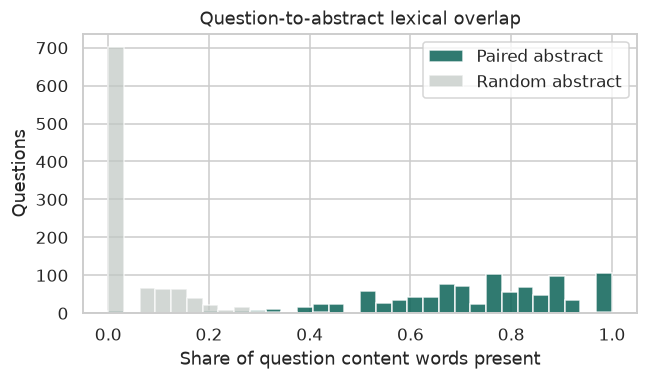

Median overlap with the **paired** abstract is **0.75**, against **0.00** for a random one. The wider that gap, the more a purely lexical method succeeds without any semantic matching at all.

In [9]:
# Compare question-to-abstract word overlap against a randomly paired abstract.
STOPWORDS = set("""a an and are as at be been by for from has have how in is it its of on or that
the this to was were what which who why with does do did can could should would will may might
between among during after before both each more most other some such than then there these
those we our you your they their""".split())


def content_words(text):
    return {w for w in re.findall(r"[a-z0-9][a-z0-9\-]+", text.lower()) if w not in STOPWORDS}


def containment(question, abstract):
    words = content_words(question)
    return len(words & content_words(abstract)) / len(words) if words else 0.0


rng = np.random.default_rng(42)
shuffled = data["abstract"].to_numpy()[rng.permutation(len(data))]
data["overlap_gold"] = [containment(q, a) for q, a in zip(data["question"], data["abstract"])]
data["overlap_random"] = [containment(q, a) for q, a in zip(data["question"], shuffled)]

fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.hist(data["overlap_gold"], bins=32, alpha=0.85, color="#0C6357", label="Paired abstract")
ax.hist(data["overlap_random"], bins=32, alpha=0.7, color="#C0C7C3", label="Random abstract")
ax.set(title="Question-to-abstract lexical overlap",
       xlabel="Share of question content words present", ylabel="Questions")
ax.legend()
save_fig(fig, "fig_03_lexical_overlap")
plt.show()

display(Markdown(
    f"Median overlap with the **paired** abstract is **{data['overlap_gold'].median():.2f}**, "
    f"against **{data['overlap_random'].median():.2f}** for a random one. The wider that gap, the "
    f"more a purely lexical method succeeds without any semantic matching at all."
))

## 4.5 How Far Do Surface Cues Alone Get?

Two controls established before any system runs, so every later number is read against them
rather than against zero. Neither uses a model: one always predicts the majority label, the other
ranks abstracts by raw word overlap with no index, weighting or embeddings.

In [10]:
# Rank every abstract by raw content-word containment, with no model involved.
def overlap_ranks(frame):
    doc_words = [content_words(a) for a in frame["abstract"]]
    ranks = []
    for i, question in enumerate(frame["question"]):
        query = content_words(question)
        if not query:
            ranks.append(0)
            continue
        scores = np.array([len(query & d) / len(query) for d in doc_words])
        order = np.argsort(-scores, kind="stable")
        ranks.append(int(np.where(order == i)[0][0]) + 1)
    return np.array(ranks)


baseline_ranks = overlap_ranks(data)
SURFACE_CUE = {
    "Majority-label accuracy": MAJORITY_ACCURACY,
    "Word overlap Recall@1": float(np.mean(baseline_ranks == 1)),
    "Word overlap Recall@5": float(np.mean(baseline_ranks <= 5)),
    "Word overlap MRR": float(np.mean(1.0 / baseline_ranks)),
}
display(pd.DataFrame(SURFACE_CUE.items(), columns=["Control", "Score"])
        .style.format({"Score": "{:.3f}"}).hide(axis="index"))

if SURFACE_CUE["Word overlap Recall@5"] > 0.90:
    display(Markdown(
        f"> **Ceiling warning.** Naive word overlap already reaches Recall@5 = "
        f"**{SURFACE_CUE['Word overlap Recall@5']:.3f}** against 1,000 abstracts. At that corpus "
        f"size the four systems would compete over a margin that barely exists, and the research "
        f"question would return no significant difference. §5.3 therefore builds a second, larger "
        f"corpus, and both are reported."
    ))

Control,Score
Majority-label accuracy,0.552
Word overlap Recall@1,0.914
Word overlap Recall@5,0.961
Word overlap MRR,0.936


> **Ceiling warning.** Naive word overlap already reaches Recall@5 = **0.961** against 1,000 abstracts. At that corpus size the four systems would compete over a margin that barely exists, and the research question would return no significant difference. §5.3 therefore builds a second, larger corpus, and both are reported.

## 4.6 Representative Records

In [11]:
# Use a fixed random state so the same representative rows appear on every run.
display(data.sample(4, random_state=42)[["question", "label", "abstract_words", "overlap_gold"]]
        .style.format({"overlap_gold": "{:.2f}"}).hide(axis="index"))

question,label,abstract_words,overlap_gold
Pap smears with glandular cell abnormalities: Are they detected by rapid prescreening?,yes,212,1.00
Are patients with Werlhof's disease at increased risk for bleeding complications when undergoing cardiac surgery?,no,233,1.00
Is there a connection between sublingual varices and hypertension?,yes,257,0.75
Does health information exchange reduce redundant imaging?,yes,263,0.83


## 4.7 EDA Summary

In [12]:
# Generate a concise summary directly from the executed analysis.
display(Markdown(f"""
- The evaluation set holds **{len(data):,} expert-labelled instances** with no duplicates, no
  empty fields and no invalid labels.
- Answers are imbalanced ({counts['yes']:.0f} yes / {counts['no']:.0f} no /
  {counts['maybe']:.0f} maybe), so **macro-F1 accompanies accuracy** throughout §7.
- Abstracts run to a median of **{data['abstract_words'].median():.0f} words** across
  {data['n_segments'].median():.0f} labelled segments, so a three-sentence chunk sits inside the
  cross-encoder window and a five-passage prompt stays well within the generator's context.
- Median question-to-abstract overlap is **{data['overlap_gold'].median():.2f}** against
  {data['overlap_random'].median():.2f} for a random abstract, and word overlap alone reaches
  **Recall@5 = {SURFACE_CUE['Word overlap Recall@5']:.3f}** over 1,000 documents. Retrieval on the
  smallest corpus is close to solved before any of this project's machinery is applied, which is
  why the corpus is built at two scales in §5.3.
"""))


- The evaluation set holds **1,000 expert-labelled instances** with no duplicates, no
  empty fields and no invalid labels.
- Answers are imbalanced (552 yes / 338 no /
  110 maybe), so **macro-F1 accompanies accuracy** throughout §7.
- Abstracts run to a median of **200 words** across
  3 labelled segments, so a three-sentence chunk sits inside the
  cross-encoder window and a five-passage prompt stays well within the generator's context.
- Median question-to-abstract overlap is **0.75** against
  0.00 for a random abstract, and word overlap alone reaches
  **Recall@5 = 0.961** over 1,000 documents. Retrieval on the
  smallest corpus is close to solved before any of this project's machinery is applied, which is
  why the corpus is built at two scales in §5.3.


# 5. Data Preparation

## 5.1 Experiment Settings

Every choice the experiment depends on is fixed here, so a supervisor can change one line and
re-run. Two settings carry an argument worth making in Chapter 3:

- **`DENSE_MODEL` is the base-size encoder, not the large variant.** Large costs roughly three
  times as much to embed for a small retrieval margin. Base is the efficient choice, not a
  weakened one.
- **`RERANKER_MODEL` is the six-layer MS MARCO cross-encoder.** It scores within 0.01 MRR@10 of
  the twelve-layer version on MS MARCO while being about eight times cheaper, and the question
  here is whether reranking helps at all, not how large a reranker can be.

In [13]:
# Fix every experimental setting in one place.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CHUNK_SENTENCES = 3          # the fixed chunking strategy required by the methodology
CHUNK_OVERLAP = 1
CORPUS_SCALES = {"Small (1k)": 0, "Large (11k)": 10_000}   # distractor abstracts added
HEADLINE_SCALE = "Large (11k)"

DENSE_MODEL = "BAAI/bge-base-en-v1.5"
QUERY_PREFIX = "Represent this sentence for searching relevant passages: "
RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
NLI_MODEL = "cross-encoder/nli-deberta-v3-base"

CANDIDATE_POOL = 100         # first-stage depth before fusion
RERANK_DEPTH = 50            # fitted on the development split in §6.4
TOP_K = 5                    # passages handed to the generator
RECALL_AT = [1, 3, 5, 10, 20]

DEV_SIZE = 300               # used only to select the best hybrid configuration
GENERATION_SAMPLE = 100      # stratified questions sent to the generator
                             # (subset of a fixed 200 draw, so the cache stays valid)
# gemini-3.5-flash allows only 20 requests per DAY on the free tier, which
# cannot serve this experiment. The lite variant of the same family is
# rate-limited per minute instead, so it can. Documented in §8.2.
GEMINI_MODEL = os.getenv("ZAIN_MODEL", "gemini-3.5-flash-lite")
THROTTLE_SECONDS = float(os.getenv("ZAIN_THROTTLE", "4.5"))  # 13/min, under the 15 cap
USE_LIVE_GENERATOR = bool(os.getenv("GOOGLE_API_KEY"))

print(f"Chunking      : {CHUNK_SENTENCES} sentences, {CHUNK_OVERLAP} overlap")
print(f"Corpus scales : {list(CORPUS_SCALES)}  (headline: {HEADLINE_SCALE})")
print(f"Dense encoder : {DENSE_MODEL}")
print(f"Reranker      : {RERANKER_MODEL}")
print(f"Generator     : {GEMINI_MODEL}  (live: {USE_LIVE_GENERATOR})")

Chunking      : 3 sentences, 1 overlap
Corpus scales : ['Small (1k)', 'Large (11k)']  (headline: Large (11k))
Dense encoder : BAAI/bge-base-en-v1.5
Reranker      : cross-encoder/ms-marco-MiniLM-L-6-v2
Generator     : gemini-3.5-flash-lite  (live: True)


## 5.2 Cleaning and Chunking

Cleaning is deliberately conservative. Biomedical text carries meaning in characters that generic
cleaning discards, so hyphenated compounds (`IL-6`), dosages (`25 mg`) and comparison operators
(`p<0.001`) all survive intact.

Chunking is fixed at three sentences with one sentence of overlap and applied identically to
paired and distractor abstracts. Three sentences keeps a question-passage pair inside the
cross-encoder window while still carrying a complete finding; the overlap prevents a claim that
straddles a boundary from being lost by both neighbours.

In [14]:
# Apply four fixed cleaning rules, then split into overlapping sentence windows.
LIGATURES = {"ﬁ": "fi", "ﬂ": "fl", "–": "-", "—": "-",
             "‘": "'", "’": "'", "“": '"', "”": '"', " ": " "}
DEHYPHEN = re.compile(r"(\w)-\s+(\w)")
WHITESPACE = re.compile(r"\s+")
ABBREVIATIONS = {"e.g", "i.e", "vs", "cf", "fig", "no", "approx", "et al", "al", "ca", "sd", "ci"}
SENTENCE_END = re.compile(r"(?<=[.!?])\s+(?=[A-Z(\[\"'])")


def clean_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    for bad, good in LIGATURES.items():
        text = text.replace(bad, good)
    text = DEHYPHEN.sub(r"\1\2", text)          # rejoin words split across a line break
    return WHITESPACE.sub(" ", text).strip()


def split_sentences(text):
    parts, output = SENTENCE_END.split(text.strip()), []
    for part in parts:
        part = part.strip()
        if not part:
            continue
        if output:
            tail = re.sub(r"[^a-z. ]", "", output[-1].lower()).strip().rstrip(".").split()
            if (tail and tail[-1] in ABBREVIATIONS) or re.search(r"\b[A-Z]\.$", output[-1]):
                output[-1] += " " + part
                continue
        output.append(part)
    return output


def chunk_abstract(text, doc_id):
    step = CHUNK_SENTENCES - CHUNK_OVERLAP
    sentences = split_sentences(text)
    if not sentences:
        return []
    if len(sentences) <= CHUNK_SENTENCES:
        windows = [sentences]
    else:
        windows = [sentences[i:i + CHUNK_SENTENCES]
                   for i in range(0, len(sentences) - CHUNK_SENTENCES + step, step)]
    return [{"chunk_id": f"{doc_id}::{i}", "doc_id": doc_id, "text": " ".join(w)}
            for i, w in enumerate(windows) if w]


probe = "Levels of  IL-6 and albumin-\nto-creatinine ratio were signiﬁcant (p<0.001)."
print("before:", repr(probe))
print("after :", repr(clean_text(probe)))
assert "IL-6" in clean_text(probe) and "p<0.001" in clean_text(probe)
print("\nCleaning preserves biomedical entities and comparison operators.")

data["abstract"] = data["abstract"].map(clean_text)
data["question"] = data["question"].map(clean_text)
data["long_answer"] = data["long_answer"].map(clean_text)

before: 'Levels of  IL-6 and albumin-\nto-creatinine ratio were signiﬁcant (p<0.001).'
after : 'Levels of IL-6 and albuminto-creatinine ratio were significant (p<0.001).'

Cleaning preserves biomedical entities and comparison operators.


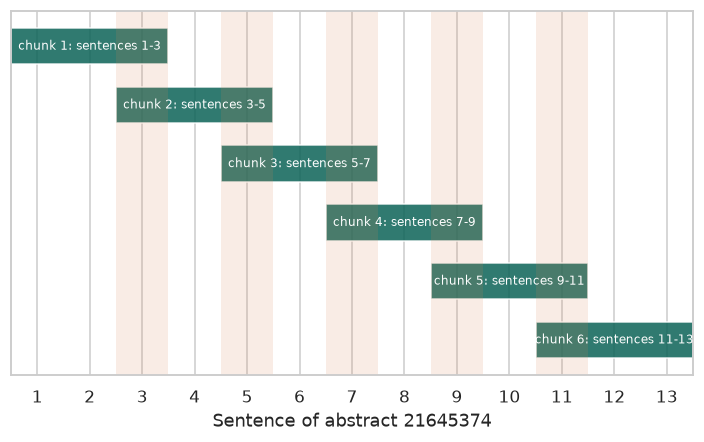

13 sentences -> 6 chunks; shaded sentences are shared by neighbouring chunks. Across the evaluation set: median 4 chunks per abstract.


In [15]:
# Show the fixed chunking windows on one real abstract from the evaluation set.
_example = data.iloc[0]
_sentences = split_sentences(_example["abstract"])
_step = CHUNK_SENTENCES - CHUNK_OVERLAP
if len(_sentences) <= CHUNK_SENTENCES:
    _starts = [0]
else:
    _starts = list(range(0, len(_sentences) - CHUNK_SENTENCES + _step, _step))
_windows = [(s, min(s + CHUNK_SENTENCES, len(_sentences))) for s in _starts]
assert len(_windows) == len(chunk_abstract(_example["abstract"], "probe"))

fig, ax = plt.subplots(figsize=(8, 0.5 * len(_windows) + 1.3))
for row, (start, end) in enumerate(_windows):
    ax.barh(row, end - start, left=start + 0.5, height=0.62, color="#0C6357", alpha=0.85)
    ax.text(start + 0.5 + (end - start) / 2, row, f"chunk {row + 1}: sentences {start + 1}-{end}",
            ha="center", va="center", color="white", fontsize=8)
for shared in range(_step, len(_sentences), _step):
    if shared < len(_sentences) - 1:
        ax.axvspan(shared + 0.5, shared + 1.5, color="#DD8452", alpha=0.15, lw=0)
ax.set(xlim=(0.5, len(_sentences) + 0.5), xticks=range(1, len(_sentences) + 1),
       xlabel=f"Sentence of abstract {_example['pubid']}", yticks=[], ylim=(len(_windows) - 0.4, -0.6))
ax.grid(axis="y", visible=False)
save_fig(fig, "fig_07_chunking")
plt.show()

_per_doc = [len(chunk_abstract(a, "x")) for a in data["abstract"]]
print(f"{len(_sentences)} sentences -> {len(_windows)} chunks; shaded sentences are shared by "
      f"neighbouring chunks. Across the evaluation set: median {np.median(_per_doc):.0f} chunks "
      f"per abstract.")

## 5.3 Retrieval Corpus at Two Scales

The corpus is built twice. The paired pool is identical in both, so every question's source
abstract is always retrievable; only the number of same-domain distractors changes.

| Scale | Abstracts | Purpose |
|---|---|---|
| Small | 1,000 | The corpus exactly as the proposal describes it |
| Large | 11,000 | Adds 10,000 unlabelled PubMedQA abstracts as distractors |

§4.5 showed why the second scale is needed: against 1,000 candidates, naive word overlap alone
already finds the right abstract most of the time, leaving the four systems to compete over a
margin that may not exist. Both are reported, so the effect of corpus difficulty is visible
rather than assumed.

**The leak guard.** Distractor abstracts are read from `context.contexts` only; their conclusions
are never touched. For the paired abstracts the guard is a provenance check — every chunk must be
a literal substring of its own cleaned abstract body — which is exact, cannot raise a false
positive, and catches any code path that mixes `long_answer` in.

In [16]:
# Build both corpora from cleaned abstracts, guarding the paired pool by provenance.
class ConclusionLeakError(AssertionError):
    """An answer key reached the retrieval corpus. Always a bug, never data."""


def normalise(text):
    return WHITESPACE.sub(" ", re.sub(r"[^a-z0-9 ]+", " ", str(text).lower())).strip()


SOURCE_TEXT = dict(zip(data["pubid"].astype(str), data["abstract"].map(normalise)))
CONCLUSION = dict(zip(data["pubid"].astype(str), data["long_answer"]))


def assert_provenance(text, doc_id, where):
    source = SOURCE_TEXT.get(doc_id)
    if source is None:
        return                                   # distractor: built from `contexts` only
    if normalise(text) not in source:
        raise ConclusionLeakError(
            f"chunk for {doc_id} in {where} is not a substring of its abstract body")


def build_corpus(n_distractors):
    chunks = []
    for row in data.itertuples():
        chunks.extend(chunk_abstract(row.abstract, str(row.pubid)))
    if n_distractors:
        picked = np.random.default_rng(RANDOM_SEED).permutation(len(unlabelled))[:n_distractors]
        for i in picked:
            record = unlabelled[int(i)]
            text = clean_text(" ".join(record["context"]["contexts"]))
            chunks.extend(chunk_abstract(text, f"U{record['pubid']}"))
    return pd.DataFrame(chunks)


CORPUS = {name: build_corpus(n) for name, n in CORPUS_SCALES.items()}

# Both guards, in both directions, or they are decoration.
for name, frame in CORPUS.items():
    paired = frame[frame["doc_id"].isin(SOURCE_TEXT)]
    for row in paired.itertuples():
        assert_provenance(row.text, row.doc_id, name)
    assert set(data["pubid"].astype(str)) <= set(paired["doc_id"]), f"{name}: missing gold doc"

probe_id = str(data.iloc[0]["pubid"])
try:
    assert_provenance(CORPUS[HEADLINE_SCALE].iloc[0]["text"] + " " + CONCLUSION[probe_id],
                      probe_id, "self-check")
except ConclusionLeakError:
    print("Leak guard rejects a deliberately poisoned chunk.")
else:
    raise AssertionError("LEAK GUARD IS BROKEN")

display(pd.DataFrame([
    {"Corpus": name, "Documents": f"{f['doc_id'].nunique():,}", "Chunks": f"{len(f):,}",
     "Median chunk words": f"{f['text'].str.split().str.len().median():.0f}"}
    for name, f in CORPUS.items()
]).style.hide(axis="index"))
print("Every paired abstract is present in both corpora, and no chunk contains its conclusion.")

Leak guard rejects a deliberately poisoned chunk.


Corpus,Documents,Chunks,Median chunk words
Small (1k),"1,000","4,403",59
Large (11k),"11,000","48,076",59


Every paired abstract is present in both corpora, and no chunk contains its conclusion.


## 5.4 Development and Test Split

The proposal commits to identifying **the best hybrid configuration** before attaching the
reranker. Choosing that configuration on the same questions the result is reported on would make
the claim circular, so a stratified development split is held out for the sweep in §6.4 and
everything in §7 is reported on the remaining questions.

In [17]:
# Draw a label-stratified development split, leaving the rest for reporting.
from sklearn.model_selection import train_test_split

dev_idx, test_idx = train_test_split(
    np.arange(len(data)), train_size=DEV_SIZE, random_state=RANDOM_SEED, stratify=data["label"])
data["split"] = "test"
data.loc[dev_idx, "split"] = "dev"

dev_set = data[data["split"] == "dev"].reset_index(drop=True)
test_set = data[data["split"] == "test"].reset_index(drop=True)

display(pd.crosstab(data["split"], data["label"], margins=True, margins_name="Total"))
print(f"Configuration is fitted on {len(dev_set)} development questions "
      f"and reported on {len(test_set)} held-out questions.")

label,maybe,no,yes,Total
split,,,,
dev,33,101,166,300
test,77,237,386,700
Total,110,338,552,1000


Configuration is fitted on 300 development questions and reported on 700 held-out questions.


## 5.5 Methodology Flowchart

Figure 1 of the proposal, drawn from the pipeline this notebook actually builds rather than the
one that was planned. Generating it here means it cannot drift from the implementation it
documents: the systems, corpus scales and evaluation layers below are read from the settings
fixed in §5.1.

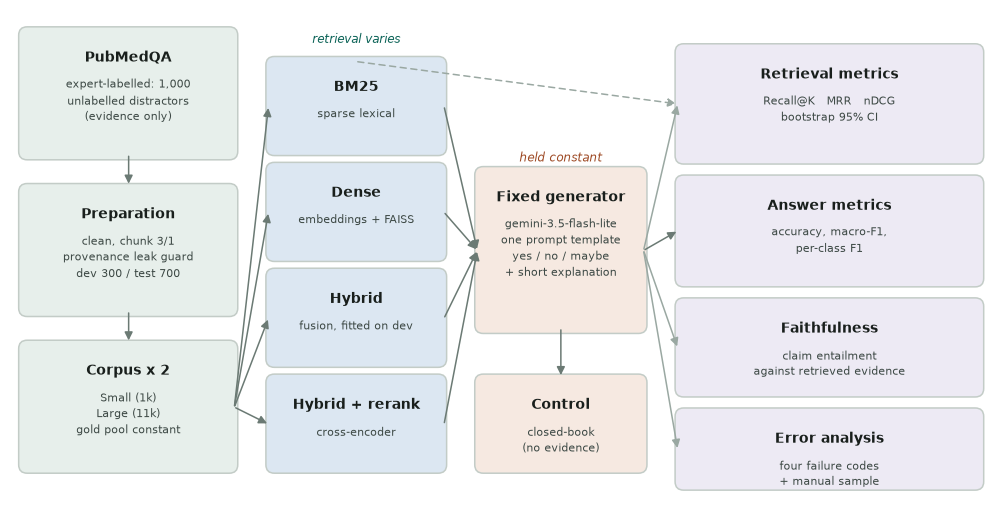

Figure 1 written to outputs/fig_00_methodology_flowchart.{png,pdf}


In [18]:
# Draw the experimental pipeline as the proposal's Figure 1.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def draw_flowchart():
    fig, ax = plt.subplots(figsize=(11.5, 5.8))
    ax.set_xlim(0, 11.5); ax.set_ylim(0, 5.8); ax.axis("off")
    EDGE = "#C3CCC7"
    FILL = {"data": "#E7EFEB", "retrieval": "#DCE7F2",
            "generation": "#F6E9E1", "evaluation": "#EDEAF4"}

    def box(x, y, w, h, title, body, kind):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06,rounding_size=0.10",
                                    linewidth=1.0, edgecolor=EDGE, facecolor=FILL[kind]))
        ax.text(x + w / 2, y + h - 0.22, title, ha="center", va="top",
                fontsize=9.2, fontweight="600", color="#191F1C")
        ax.text(x + w / 2, y + h - 0.52, body, ha="center", va="top",
                fontsize=7.3, color="#3D4945", linespacing=1.45)

    def arrow(x1, y1, x2, y2, colour="#6B7A74", ls="-"):
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=11,
                                     linewidth=1.0, color=colour, linestyle=ls,
                                     shrinkA=1, shrinkB=1))

    small, large = list(CORPUS_SCALES)
    box(0.15, 4.10, 2.45, 1.45, "PubMedQA",
        f"expert-labelled: {len(data):,}\nunlabelled distractors\n(evidence only)", "data")
    box(0.15, 2.25, 2.45, 1.45, "Preparation",
        f"clean, chunk {CHUNK_SENTENCES}/{CHUNK_OVERLAP}\nprovenance leak guard\n"
        f"dev {len(dev_set)} / test {len(test_set)}", "data")
    box(0.15, 0.40, 2.45, 1.45, "Corpus x 2",
        f"{small}\n{large}\ngold pool constant", "data")

    box(3.05, 4.15, 2.00, 1.05, "BM25", "sparse lexical", "retrieval")
    box(3.05, 2.90, 2.00, 1.05, "Dense", "embeddings + FAISS", "retrieval")
    box(3.05, 1.65, 2.00, 1.05, "Hybrid", "fusion, fitted on dev", "retrieval")
    box(3.05, 0.40, 2.00, 1.05, "Hybrid + rerank", "cross-encoder", "retrieval")

    box(5.50, 2.05, 1.90, 1.85, "Fixed generator",
        f"{GEMINI_MODEL}\none prompt template\nyes / no / maybe\n+ short explanation", "generation")
    box(5.50, 0.40, 1.90, 1.05, "Control", "closed-book\n(no evidence)", "generation")

    box(7.85, 4.05, 3.50, 1.30, "Retrieval metrics",
        "Recall@K   MRR   nDCG\nbootstrap 95% CI", "evaluation")
    box(7.85, 2.60, 3.50, 1.20, "Answer metrics",
        "accuracy, macro-F1,\nper-class F1", "evaluation")
    box(7.85, 1.30, 3.50, 1.05, "Faithfulness",
        "claim entailment\nagainst retrieved evidence", "evaluation")
    box(7.85, 0.20, 3.50, 0.85, "Error analysis",
        "four failure codes\n+ manual sample", "evaluation")

    arrow(1.38, 4.10, 1.38, 3.74)
    arrow(1.38, 2.25, 1.38, 1.89)
    for y in (4.67, 3.42, 2.17, 0.92):
        arrow(2.62, 1.12, 3.02, y)
        arrow(5.08, y, 5.47, 2.97)
    arrow(6.45, 2.05, 6.45, 1.48)
    arrow(7.42, 2.97, 7.82, 3.20)
    for y in (4.70, 1.82, 0.62):
        arrow(7.42, 2.97, 7.82, y, colour="#9AA8A2")
    arrow(4.05, 5.20, 7.82, 4.70, colour="#9AA8A2", ls=(0, (4, 3)))

    ax.text(4.05, 5.42, "retrieval varies", ha="center", fontsize=8,
            style="italic", color="#0C6357")
    ax.text(6.45, 4.02, "held constant", ha="center", fontsize=8,
            style="italic", color="#9E4A25")
    return fig


save_fig(draw_flowchart(), "fig_00_methodology_flowchart")
plt.show()
print("Figure 1 written to outputs/fig_00_methodology_flowchart.{png,pdf}")

# 6. RAG Implementation

Four retrieval systems behind one interface, then a single generator that sees only what the
retriever gave it. Nothing below this point knows which system it is serving, which is what makes
the claim in §1 — that retrieval is the only thing varying — a property of the code rather than a
promise in the write-up.

## 6.1 Sparse Retrieval (BM25)

The tokeniser keeps hyphens and digits. A generic `\w\w+` pattern would split `IL-6` into `il`
plus a discarded character and shatter `albumin-to-creatinine` into three unrelated tokens,
destroying precisely the rare, discriminative terms that are BM25's advantage in this domain.

In [19]:
# Index every corpus with Okapi BM25 over a biomedical-aware tokenisation.
import bm25s
import Stemmer

TOKEN_PATTERN = r"(?u)\b\w[\w\-]+\b"      # keeps IL-6, HbA1c, albumin-to-creatinine
stemmer = Stemmer.Stemmer("english")


def tokenise(texts):
    return bm25s.tokenize(texts, stopwords="en", stemmer=stemmer,
                          token_pattern=TOKEN_PATTERN, show_progress=False)


BM25_INDEX = {}
for name, frame in CORPUS.items():
    index = bm25s.BM25(k1=1.5, b=0.75)
    index.index(tokenise(frame["text"].tolist()), show_progress=False)
    BM25_INDEX[name] = index
    print(f"{name}: BM25 indexed {len(frame):,} chunks")

Small (1k): BM25 indexed 4,403 chunks


Large (11k): BM25 indexed 48,076 chunks


## 6.2 Dense Retrieval and the FAISS Index

Chunks are embedded once per corpus and searched with an exact inner-product index over
L2-normalised vectors. At this corpus size exhaustive search costs seconds, so there is no reason
to accept the approximation error of an approximate index.

A document takes the score of its **best** chunk, and that chunk travels forward. Max-pooling
rather than summing matters: summing would reward long abstracts simply for producing more
chunks, which is a length bias unrelated to relevance. Carrying the winning chunk means the
reranker later scores one representative passage per candidate, and the evidence shown to the
generator is the evidence that actually won the ranking.

In [20]:
# Encode each corpus once, then wrap it in an exact FAISS index.
import faiss
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer(DENSE_MODEL)
BATCH = 256 if os.getenv("CUDA_VISIBLE_DEVICES") or faiss.get_num_gpus() else 32

DENSE_INDEX, CHUNK_LOOKUP = {}, {}
for name, frame in CORPUS.items():
    cache = OUTPUT_DIR / f"embeddings_{name.split()[0].lower()}.npy"
    if cache.exists():
        vectors = np.load(cache)
        print(f"{name}: loaded cached embeddings {vectors.shape}")
    else:
        started = time.perf_counter()
        vectors = encoder.encode(frame["text"].tolist(), batch_size=BATCH,
                                 normalize_embeddings=True, show_progress_bar=True)
        np.save(cache, vectors)
        print(f"{name}: embedded {len(frame):,} chunks in "
              f"{(time.perf_counter() - started) / 60:.1f} min")
    index = faiss.IndexFlatIP(vectors.shape[1])
    index.add(vectors.astype("float32"))
    DENSE_INDEX[name] = index
    CHUNK_LOOKUP[name] = {
        "ids": frame["chunk_id"].to_numpy(),
        "doc": dict(zip(frame["chunk_id"], frame["doc_id"])),
        "text": dict(zip(frame["chunk_id"], frame["text"])),
    }

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Small (1k): loaded cached embeddings (4403, 768)


Large (11k): loaded cached embeddings (48076, 768)


In [21]:
# Max-pool chunk scores to their parent documents, keeping the chunk that won.
def pool_to_documents(chunk_ids, scores, lookup, top_n):
    best = {}
    for chunk_id, score in zip(chunk_ids, scores):
        doc = lookup["doc"][chunk_id]
        if score > best.get(doc, (-np.inf, None))[0]:
            best[doc] = (float(score), chunk_id)
    ranked = sorted(best.items(), key=lambda kv: -kv[1][0])[:top_n]
    return [(doc, score, chunk_id) for doc, (score, chunk_id) in ranked]


def retrieve_bm25(questions, scale, top_n):
    lookup = CHUNK_LOOKUP[scale]
    k = min(top_n * 6, len(lookup["ids"]))
    idx, scores = BM25_INDEX[scale].retrieve(tokenise(questions), k=k, show_progress=False)
    return [pool_to_documents(lookup["ids"][idx[i]], scores[i], lookup, top_n)
            for i in range(len(questions))]


def retrieve_dense(questions, scale, top_n):
    lookup = CHUNK_LOOKUP[scale]
    vectors = encoder.encode([QUERY_PREFIX + q for q in questions], batch_size=BATCH,
                             normalize_embeddings=True, show_progress_bar=False)
    k = min(top_n * 6, DENSE_INDEX[scale].ntotal)
    scores, idx = DENSE_INDEX[scale].search(vectors.astype("float32"), k)
    return [pool_to_documents(lookup["ids"][idx[i]], scores[i], lookup, top_n)
            for i in range(len(questions))]


sample_questions = test_set["question"].head(3).tolist()
sample_gold = test_set["pubid"].head(3).astype(str).tolist()
for label, fn in (("BM25", retrieve_bm25), ("Dense", retrieve_dense)):
    hits = fn(sample_questions, HEADLINE_SCALE, 5)
    print(f"{label:<6} gold in top-5: {[g in [h[0] for h in r] for g, r in zip(sample_gold, hits)]}")

BM25   gold in top-5: [True, True, True]


Dense  gold in top-5: [True, True, True]


## 6.3 Hybrid Fusion

Two fusion methods are implemented and compared rather than one being assumed. **Reciprocal rank
fusion** sums `1 / (k + rank)` across both rankings and needs no calibration, which matters
because a BM25 score and a cosine similarity are not on comparable scales. Its weakness is that it
discards score margins entirely. **Weighted min-max fusion** normalises each ranking into `[0, 1]`
and takes a convex combination, keeping those margins at the cost of a weight that has to be
fitted. Which one is used is decided on the development split in §6.4.

In [22]:
# Combine the two ranked lists, carrying the winning chunk with each document.
def minmax(values):
    values = np.asarray(values, dtype=float)
    low, high = values.min(), values.max()
    return np.zeros_like(values) if high - low < 1e-12 else (values - low) / (high - low)


def fuse(sparse_hits, dense_hits, method, rrf_k, alpha, top_n):
    scores, chunk_of, best = defaultdict(float), {}, {}
    if method == "rrf":
        for hits in (sparse_hits, dense_hits):
            for rank, (doc, score, chunk_id) in enumerate(hits, start=1):
                scores[doc] += 1.0 / (rrf_k + rank)
                if score > best.get(doc, -np.inf):
                    best[doc], chunk_of[doc] = score, chunk_id
    else:
        for hits, weight in ((sparse_hits, 1 - alpha), (dense_hits, alpha)):
            if not hits:
                continue
            for (doc, _raw, chunk_id), norm in zip(hits, minmax([s for _, s, _ in hits])):
                scores[doc] += weight * float(norm)
                if norm > best.get(doc, -np.inf):
                    best[doc], chunk_of[doc] = float(norm), chunk_id
    ranked = sorted(scores.items(), key=lambda kv: -kv[1])[:top_n]
    return [(doc, score, chunk_of[doc]) for doc, score in ranked]


def retrieve_hybrid(questions, scale, top_n, method="rrf", rrf_k=60, alpha=0.5):
    sparse = retrieve_bm25(questions, scale, CANDIDATE_POOL)
    dense = retrieve_dense(questions, scale, CANDIDATE_POOL)
    return [fuse(s, d, method, rrf_k, alpha, top_n) for s, d in zip(sparse, dense)]


hits = retrieve_hybrid(sample_questions, HEADLINE_SCALE, 5)
print(f"Hybrid gold in top-5: {[g in [h[0] for h in r] for g, r in zip(sample_gold, hits)]}")

Hybrid gold in top-5: [True, True, True]


## 6.4 Cross-Encoder Reranking and Configuration Selection

A bi-encoder compresses a passage into a fixed vector before it ever sees the question. A
cross-encoder reads the pair jointly, so attention can connect a question's `albuminuria` to a
passage's negation of it. That is the interaction reranking exists for, and the reason it costs
more.

Two properties are worth stating because they shape the results. Reranking **cannot recover a
document the first stage never retrieved** — it reorders a pool, so candidate coverage is the
hard ceiling on what it can achieve. And its cost is `questions × depth`, **independent of corpus
size**, which is what keeps the larger corpus affordable here.

The sweep below selects the fusion method, its constant and the reranking depth on the
development split only. The chosen configuration is then frozen before anything in §7 runs.

In [23]:
# Score one representative passage per candidate, then sweep the configuration on dev only.
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(RERANKER_MODEL, max_length=320)


def rerank_scores(questions, candidates, scale, depth):
    lookup = CHUNK_LOOKUP[scale]
    pairs, spans = [], []
    for question, cands in zip(questions, candidates):
        start = len(pairs)
        pairs.extend((question, lookup["text"][chunk_id]) for _d, _s, chunk_id in cands[:depth])
        spans.append(start)
    if not pairs:
        return [[] for _ in questions]
    scores = reranker.predict(pairs, batch_size=BATCH, show_progress_bar=len(pairs) > 4000)
    output = []
    for cands, start in zip(candidates, spans):
        output.append([(doc, float(scores[start + j]), chunk_id)
                       for j, (doc, _s, chunk_id) in enumerate(cands[:depth])])
    return output


def rerank(questions, candidates, scale, top_n, depth=None):
    scored = rerank_scores(questions, candidates, scale, depth or RERANK_DEPTH)
    return [sorted(s, key=lambda t: -t[1])[:top_n] for s in scored]


def gold_rank(hits, gold_id):
    for position, hit in enumerate(hits, start=1):
        if hit[0] == gold_id:
            return position
    return 0


def mrr_at_k(ranks, k=10):
    ranks = np.asarray(ranks)
    hit = (ranks >= 1) & (ranks <= k)
    return float(np.mean(np.where(hit, 1.0 / np.maximum(ranks, 1), 0.0)))

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [24]:
# Sweep fusion on the development split, then reranking depth for the winning fusion.
dev_questions = dev_set["question"].tolist()
dev_gold = dev_set["pubid"].astype(str).tolist()

fusion_grid = ([{"method": "rrf", "rrf_k": k} for k in (10, 20, 60, 100)]
               + [{"method": "weighted", "alpha": a} for a in (0.1, 0.3, 0.5, 0.7, 0.9)])

SWEEP_CACHE = OUTPUT_DIR / "sweep_results.json"
sweep = []
if SWEEP_CACHE.exists():
    cached_sweep = json.loads(SWEEP_CACHE.read_text())
    sweep = cached_sweep["sweep"]
    print(f"Loaded cached sweep from {SWEEP_CACHE.name} - delete it to re-fit.")
for candidate in ([] if sweep else fusion_grid):
    hits = retrieve_hybrid(dev_questions, HEADLINE_SCALE, 20, **candidate)
    ranks = [gold_rank(h, g) for h, g in zip(hits, dev_gold)]
    sweep.append({**candidate, "MRR@10": mrr_at_k(ranks)})

fusion_table = pd.DataFrame(sweep).sort_values("MRR@10", ascending=False)
if not SWEEP_CACHE.exists():
    SWEEP_CACHE.write_text(json.dumps({"sweep": sweep}))
BEST_FUSION = {k: v for k, v in fusion_table.iloc[0].items()
               if k != "MRR@10" and pd.notna(v)}
display(fusion_table.style.format({"MRR@10": "{:.4f}"}, na_rep="-").hide(axis="index"))
print(f"Best fusion on the development split: {BEST_FUSION}")

Loaded cached sweep from sweep_results.json - delete it to re-fit.


method,rrf_k,MRR@10,alpha
weighted,-,0.9553,0.700000
weighted,-,0.9541,0.500000
weighted,-,0.9521,0.900000
rrf,10.000000,0.9482,-
rrf,20.000000,0.9467,-
rrf,60.000000,0.9434,-
rrf,100.000000,0.9430,-
weighted,-,0.9410,0.300000
weighted,-,0.9146,0.100000


Best fusion on the development split: {'method': 'weighted', 'alpha': np.float64(0.7)}


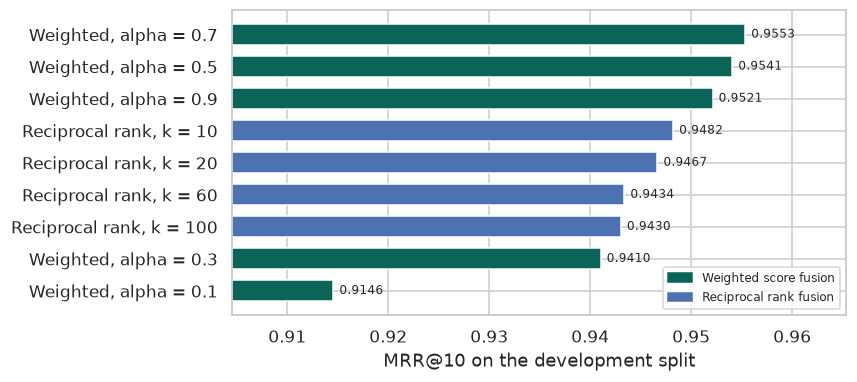

In [25]:
# Rank every fusion configuration by its development-split score.
def _fusion_label(row):
    if row["method"] == "rrf":
        return f"Reciprocal rank, k = {int(row['rrf_k'])}"
    return f"Weighted, alpha = {row['alpha']:.1f}"


_fusion_plot = fusion_table.assign(Configuration=fusion_table.apply(_fusion_label, axis=1)).iloc[::-1]
_fusion_colour = {"weighted": "#0C6357", "rrf": "#4C72B0"}
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.barh(_fusion_plot["Configuration"], _fusion_plot["MRR@10"],
        color=[_fusion_colour[m] for m in _fusion_plot["method"]], height=0.65)
for y, value in enumerate(_fusion_plot["MRR@10"]):
    ax.text(value + 0.0006, y, f"{value:.4f}", va="center", fontsize=8)
ax.set(xlim=(_fusion_plot["MRR@10"].min() - 0.01, _fusion_plot["MRR@10"].max() + 0.01),
       xlabel="MRR@10 on the development split")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=_fusion_colour["weighted"], label="Weighted score fusion"),
                   Patch(color=_fusion_colour["rrf"], label="Reciprocal rank fusion")],
          fontsize=8, loc="lower right")
save_fig(fig, "fig_08_fusion_sweep")
plt.show()

In [26]:
# Score the deepest pool once; shallower depths are restrictions of the same scores.
DEPTH_CACHE = OUTPUT_DIR / "depth_sweep.json"
if DEPTH_CACHE.exists():
    depth_rows = json.loads(DEPTH_CACHE.read_text())
    print(f"Loaded cached depth sweep from {DEPTH_CACHE.name} - delete it to re-fit.")
else:
    dev_candidates = retrieve_hybrid(dev_questions, HEADLINE_SCALE, CANDIDATE_POOL, **BEST_FUSION)
    deep = rerank_scores(dev_questions, dev_candidates, HEADLINE_SCALE, 100)
    depth_rows = []
    for depth in (20, 50, 100):
        ranks = [gold_rank(sorted(s[:depth], key=lambda t: -t[1])[:20], g)
                 for s, g in zip(deep, dev_gold)]
        depth_rows.append({"Depth": depth, "MRR@10": mrr_at_k(ranks),
                           "Cross-encoder pairs": len(dev_questions) * depth})
    DEPTH_CACHE.write_text(json.dumps(depth_rows))

depth_table = pd.DataFrame(depth_rows)
RERANK_DEPTH = int(depth_table.sort_values("MRR@10", ascending=False).iloc[0]["Depth"])
display(depth_table.style.format({"MRR@10": "{:.4f}",
                                  "Cross-encoder pairs": "{:,.0f}"}).hide(axis="index"))

display(Markdown(f"""
**Selected configuration:** fusion `{BEST_FUSION}`, reranking depth **{RERANK_DEPTH}**.

Fitted on {len(dev_set)} development questions and frozen here. Everything reported in §7 is
measured on the {len(test_set)} held-out questions under this configuration, so the
"best configuration" claim is not circular.
"""))

Loaded cached depth sweep from depth_sweep.json - delete it to re-fit.


Depth,MRR@10,Cross-encoder pairs
20,0.9228,"6,000"
50,0.9214,"15,000"
100,0.9210,"30,000"



**Selected configuration:** fusion `{'method': 'weighted', 'alpha': np.float64(0.7)}`, reranking depth **20**.

Fitted on 300 development questions and frozen here. Everything reported in §7 is
measured on the 700 held-out questions under this configuration, so the
"best configuration" claim is not circular.


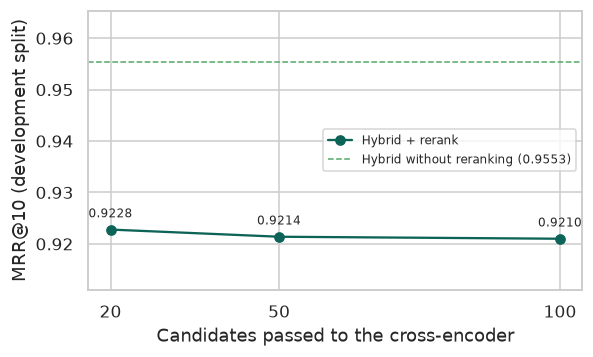

In [27]:
# Plot reranking depth against ordering quality, beside the unreranked hybrid for reference.
fig, ax = plt.subplots(figsize=(5.8, 3.3))
ax.plot(depth_table["Depth"], depth_table["MRR@10"], marker="o",
        color=SYSTEM_COLOURS["hybrid_rerank"], label="Hybrid + rerank")
for depth, value in zip(depth_table["Depth"], depth_table["MRR@10"]):
    ax.annotate(f"{value:.4f}", (depth, value), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8)
_no_rerank = float(fusion_table.iloc[0]["MRR@10"])
ax.axhline(_no_rerank, ls="--", lw=1, color=SYSTEM_COLOURS["hybrid"],
           label=f"Hybrid without reranking ({_no_rerank:.4f})")
ax.set(xticks=depth_table["Depth"], xlabel="Candidates passed to the cross-encoder",
       ylabel="MRR@10 (development split)",
       ylim=(depth_table["MRR@10"].min() - 0.01, _no_rerank + 0.01))
ax.legend(fontsize=8, loc="center right")
save_fig(fig, "fig_11_depth_sweep")
plt.show()

## 6.5 One Retrieval Interface

Below this line nothing knows which retrieval system it is serving.

In [28]:
# Route every system through a single entry point.
def retrieve(system, questions, scale, top_n):
    if system in ("closed_book", "oracle"):
        return [[] for _ in questions]
    if system == "bm25":
        return retrieve_bm25(questions, scale, top_n)
    if system == "dense":
        return retrieve_dense(questions, scale, top_n)
    if system == "hybrid":
        return retrieve_hybrid(questions, scale, top_n, **BEST_FUSION)
    if system == "hybrid_rerank":
        candidates = retrieve_hybrid(questions, scale, CANDIDATE_POOL, **BEST_FUSION)
        return rerank(questions, candidates, scale, top_n, RERANK_DEPTH)
    raise ValueError(system)


print("Retrieval interface ready for:", RETRIEVAL_SYSTEMS)

Retrieval interface ready for: ['bm25', 'dense', 'hybrid', 'hybrid_rerank']


## 6.6 Answer Generation

One prompt template, used identically by every system, so the only thing that varies between
conditions is the evidence block. The generator is asked for a yes / no / maybe decision and a
short supporting explanation, constrained to the retrieved passages.

Without an API key the notebook runs a deterministic offline generator instead. Every table and
figure below is still produced, but those answer-level numbers describe the machinery rather than
the method, and §8.1 says so in its own output rather than leaving the reader to notice.

In [29]:
# Build one prompt for every system, and refuse to send one that carries the conclusion.
PROMPT_TEMPLATE = """You are answering a biomedical research question for a systematic review.

Answer using ONLY the evidence passages provided below. Do not use knowledge that is not present
in those passages. If the evidence is insufficient to decide, answer "maybe".

{evidence}

Question: {question}

Respond with JSON only, in exactly this form:
{{"decision": "yes" | "no" | "maybe", "explanation": "<one or two sentences citing the evidence>"}}
"""


def build_prompt(question, passages):
    evidence = ("Evidence passages: (none provided)" if not passages else
                "\n".join(f"[{i}] {p['text']}" for i, p in enumerate(passages, start=1)))
    return PROMPT_TEMPLATE.format(evidence=evidence, question=question)


def passages_for(system, question, gold_id, scale):
    lookup = CHUNK_LOOKUP[scale]

    # The oracle condition answers the supervisor's question of whether failures come from
    # retrieving the wrong evidence or from misreading the right evidence. It is handed the
    # chunks of the paired abstract directly, so retrieval is perfect by construction and any
    # remaining error must originate in the generator.
    if system == "oracle":
        chunks = [cid for cid, doc in lookup["doc"].items() if doc == gold_id][:TOP_K]
        return [{"doc_id": gold_id, "chunk_id": cid, "text": lookup["text"][cid],
                 "score": 1.0} for cid in chunks]

    hits = retrieve(system, [question], scale, TOP_K)[0]
    return [{"doc_id": doc, "chunk_id": chunk_id, "text": lookup["text"][chunk_id],
             "score": float(score)} for doc, score, chunk_id in hits]


PROMPT_HASH = hashlib.sha256(PROMPT_TEMPLATE.encode()).hexdigest()[:16]
print(f"Prompt template hash: {PROMPT_HASH}")
print(build_prompt("Does albuminuria predict progression?",
                   [{"text": "Albuminuria was measured at baseline in 1,247 adults."}]))

Prompt template hash: fe18341a12c25cfd
You are answering a biomedical research question for a systematic review.

Answer using ONLY the evidence passages provided below. Do not use knowledge that is not present
in those passages. If the evidence is insufficient to decide, answer "maybe".

[1] Albuminuria was measured at baseline in 1,247 adults.

Question: Does albuminuria predict progression?

Respond with JSON only, in exactly this form:
{"decision": "yes" | "no" | "maybe", "explanation": "<one or two sentences citing the evidence>"}



In [30]:
# Call Gemini when a key is present, and a deterministic stand-in when it is not.
JSON_BLOCK = re.compile(r"\{.*\}", re.S)
VALID = {"yes", "no", "maybe"}
CACHE_PATH = OUTPUT_DIR / "gemini_cache.json"
_cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
print(f"Response cache: {len(_cache):,} answers already on disk.")


class DailyQuotaReached(RuntimeError):
    """The free tier's daily allowance is spent. Re-run tomorrow; progress is saved."""


def offline_answer(prompt, passages):
    # Deterministic and label-blind, but grounded in the passage actually retrieved.
    seed = int(hashlib.sha256(prompt.encode()).hexdigest()[:8], 16)
    decision = ["yes", "no", "maybe"][seed % 3]
    if passages:
        sentences = split_sentences(passages[0]["text"])
        claim = sentences[0] if sentences else passages[0]["text"][:180]
        explanation = f"The retrieved evidence states: {claim} On this basis the answer is {decision}."
    else:
        explanation = f"No evidence was retrieved, so the answer is {decision}."
    return json.dumps({"decision": decision, "explanation": explanation})


if USE_LIVE_GENERATOR:
    from google import genai
    from google.genai import types
    client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])


QUOTA_WAIT_SECONDS = 45


def generate(prompt, passages, attempts=8):
    key = hashlib.sha256(f"{prompt}|{GEMINI_MODEL}".encode()).hexdigest()
    if key in _cache:
        return _cache[key]
    if not USE_LIVE_GENERATOR:
        _cache[key] = offline_answer(prompt, passages)
        return _cache[key]
    for attempt in range(attempts):
        try:
            response = client.models.generate_content(
                model=GEMINI_MODEL, contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=0, max_output_tokens=512,
                    response_mime_type="application/json"))
            _cache[key] = response.text or ""
            # Persist after every call: a run interrupted by quota loses nothing.
            CACHE_PATH.write_text(json.dumps(_cache))
            time.sleep(THROTTLE_SECONDS)        # stay inside the free tier's rate limit
            return _cache[key]
        except Exception as error:
            message = str(error)
            if "429" in message:
                # Free-tier limits roll rather than resetting at midnight, so a refusal is
                # usually temporary. Wait it out repeatedly before concluding the allowance
                # is genuinely spent.
                if attempt < attempts - 1:
                    time.sleep(QUOTA_WAIT_SECONDS)
                    continue
                raise DailyQuotaReached(
                    f"the free tier refused {attempts} consecutive attempts over "
                    f"{attempts * QUOTA_WAIT_SECONDS / 60:.0f} minutes; re-run this cell later "
                    f"and it will resume from the cache") from error
            if attempt == attempts - 1:
                raise
            time.sleep(min(2 ** attempt, 30))


def parse_answer(text):
    # A response that cannot be parsed is counted as a parse failure, never coerced to a label.
    match = JSON_BLOCK.search(text or "")
    if match:
        try:
            obj = json.loads(match.group(0))
            decision = str(obj.get("decision", "")).strip().lower()
            if decision in VALID:
                return decision, str(obj.get("explanation", "")).strip(), True
        except json.JSONDecodeError:
            pass
    for decision in ("maybe", "yes", "no"):
        if re.match(rf"^\W*{decision}\b", (text or "").strip().lower()[:40]):
            return decision, (text or "").strip(), True
    return None, (text or "").strip(), False


print(f"Generator ready ({'Gemini ' + GEMINI_MODEL if USE_LIVE_GENERATOR else 'offline stand-in'}).")

Response cache: 824 answers already on disk.


Generator ready (Gemini gemini-3.5-flash-lite).


## 6.7 Answer Support Verification

The proposal asks for a RAGAS-style evidence-support check. RAGAS faithfulness is a two-step
algorithm: decompose the answer into atomic claims, then verify each against the retrieved
context (Es et al., 2024). Both steps are kept local here, for reasons that are methodological
before they are practical.

The generator is constrained to a short explanation, so its sentences already **are** atomic
claims — using a model to split two sentences into two claims would only add a way to invent
claims the answer never made. Verification is a natural-language-inference cross-encoder:
deterministic, reproducible without API access, and free of the position, verbosity and
self-enhancement biases documented in LLM judges. Scoring a Gemini answer with a Gemini judge
would reproduce exactly the bias the literature review warns about.

Context precision and recall need no model at all, since the paired `pubid` is known.

In [31]:

# Verify each claim against the passages the answer was actually given.
nli = CrossEncoder(NLI_MODEL, max_length=512)
ENTAIL_INDEX = next(i for i, label in nli.model.config.id2label.items()
                    if str(label).lower().startswith("entail"))
print(f"NLI labels: {dict(nli.model.config.id2label)} (entailment index {ENTAIL_INDEX})")

# The generator writes in citation style - "Evidence [1] states that X" - which an entailment
# model correctly scores as neutral, because a claim *about a document* is not entailed by the
# document's content. Measuring those unstripped reports near-zero faithfulness for answers that
# are in fact well grounded, so the frame is removed and the bare proposition is scored.
CITATION_FRAME = re.compile(
    r"^\s*(?:based on|according to|as (?:stated|shown|reported|described)(?:\s+in)?|per|from)\s+"
    r"(?:the\s+)?(?:provided\s+|retrieved\s+|given\s+)*(?:evidence\s+)?"
    r"(?:passages?|evidence|context|text|documents?|information)\s*(?:\[\d+\])?\s*[,:]?\s*"
    r"|^\s*(?:the\s+)?(?:provided\s+|retrieved\s+|given\s+)*"
    r"(?:evidence|passages?|context|text|documents?)\s*(?:\[\d+\])?\s*"
    r"(?:explicitly\s+|clearly\s+|directly\s+|only\s+)?"
    r"(?:states?|shows?|indicates?|suggests?|reports?|demonstrates?|confirms?|notes?"
    r"|mentions?|discusses?|describes?|finds?|concludes?)\s*(?:that\s+)?[:,]?\s*"
    r"|^\s*passages?\s*\[\d+\]\s*(?:and\s*\[\d+\]\s*)?"
    r"(?:states?|shows?|indicates?|mentions?|discusses?)?\s*(?:that\s+)?[:,]?\s*"
    r"|^\s*\[\d+\]\s*", re.I)

# An explicit statement that the evidence does not cover the question is not an assertion about
# the world, so it cannot be entailed by anything. Counting it as unfaithful would penalise the
# model for behaving correctly. These are separated out and reported as an abstention rate.
ABSTENTION = re.compile(
    r"\b(?:do(?:es)? not (?:contain|provide|mention|address|discuss|include|specify)"
    r"|no (?:information|evidence|data|mention)"
    r"|insufficient (?:evidence|information|context)"
    r"|not (?:enough|sufficient) (?:evidence|information)"
    r"|is silent on|are empty|is empty)\b", re.I)


def strip_citation_frame(claim):
    previous = None
    while previous != claim:
        previous = claim
        claim = CITATION_FRAME.sub("", claim).strip()
    return (claim[0].upper() + claim[1:]) if claim else claim


def entailment(premises, hypotheses):
    if not premises:
        return np.zeros(0)
    logits = np.atleast_2d(np.asarray(
        nli.predict(list(zip(premises, hypotheses)), batch_size=BATCH,
                    show_progress_bar=len(premises) > 2000, apply_softmax=False), dtype=float))
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    return (exp / exp.sum(axis=1, keepdims=True))[:, ENTAIL_INDEX]


def faithfulness(explanation, passages, threshold=0.5):
    """Share of asserted claims entailed by the retrieved evidence.

    Returns (faithfulness, n_assertions, n_abstentions). Faithfulness is NaN when the answer
    made no assertion - either it abstained, or no evidence was retrieved to check against.
    """
    sentences = [s for s in split_sentences(explanation or "") if len(s.split()) >= 4]
    abstentions = [s for s in sentences if ABSTENTION.search(s)]
    assertions = [strip_citation_frame(s) for s in sentences if not ABSTENTION.search(s)]
    assertions = [a for a in assertions if len(a.split()) >= 4]
    if not assertions or not passages:
        return np.nan, 0, len(abstentions)
    premise = " ".join(p["text"] for p in passages)
    scores = entailment([premise] * len(assertions), assertions)
    return float(np.mean(scores >= threshold)), len(assertions), len(abstentions)


def evidence_grounding(explanation, passages):
    """Share of the explanation's content words that appear in the retrieved passages.

    Entailment is the stricter measure but it is a poor fit for descriptive answers: this
    generator often writes "a study was conducted to determine X", which is a statement *about*
    the document rather than a proposition the document asserts, so an NLI model correctly
    declines to call it entailed. Lexical grounding asks the weaker but well-matched question -
    is the explanation built from words that are actually in the evidence, or from elsewhere?
    """
    if not passages:
        return np.nan
    words = content_words(explanation or "")
    if not words:
        return np.nan
    evidence = content_words(" ".join(p["text"] for p in passages))
    return len(words & evidence) / len(words)


# Self-check: the fix must turn a correctly-grounded citation-style claim from neutral to entailed.
_premise = [{"text": "Sternal fractures in childhood are rare injuries, occurring in fewer "
                     "than 1% of paediatric trauma admissions."}]
_framed = "Evidence [1] explicitly states that sternal fractures in childhood are rare."
_before = entailment([_premise[0]["text"]], [_framed])[0]
_after = entailment([_premise[0]["text"]], [strip_citation_frame(_framed)])[0]
print(f"citation-framed claim  entailment {_before:.3f}  ->  stripped {_after:.3f}")
assert _after > _before, "frame stripping must improve entailment on a grounded claim"
print("Faithfulness verifier ready.")


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

NLI labels: {0: 'contradiction', 1: 'entailment', 2: 'neutral'} (entailment index 1)


citation-framed claim  entailment 0.001  ->  stripped 0.997
Faithfulness verifier ready.


# 7. Evaluation and Results

Four measurement layers, each answering a different question and reported separately rather than
averaged into one score: whether the right abstract was retrieved at all, how early it appeared,
whether the answer was correct, and whether the explanation was supported by the evidence.

## 7.1 Evaluation Metrics

In [32]:
# Retrieval metrics, plus the bootstrap interval used on every headline figure.
def recall_at_k(ranks, k):
    ranks = np.asarray(ranks)
    return float(np.mean((ranks >= 1) & (ranks <= k)))


def ndcg_at_k(ranks, k=10):
    # A single binary relevant document, so the ideal gain is 1 and nDCG = 1 / log2(rank + 1).
    ranks = np.asarray(ranks)
    hit = (ranks >= 1) & (ranks <= k)
    return float(np.mean(np.where(hit, 1.0 / np.log2(np.maximum(ranks, 1) + 1), 0.0)))


def retrieval_summary(ranks):
    summary = {f"Recall@{k}": recall_at_k(ranks, k) for k in RECALL_AT}
    summary["MRR@10"] = mrr_at_k(ranks)
    summary["nDCG@10"] = ndcg_at_k(ranks)
    return summary


def bootstrap_ci(values, n_boot=10_000, alpha=0.05):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(RANDOM_SEED)
    draws = values[rng.integers(0, len(values), size=(n_boot, len(values)))].mean(axis=1)
    return (float(values.mean()), float(np.percentile(draws, 100 * alpha / 2)),
            float(np.percentile(draws, 100 * (1 - alpha / 2))))


# Self-checks against hand-computed answers.
assert recall_at_k([1, 1], 5) == 1.0 and mrr_at_k([1]) == 1.0 and ndcg_at_k([1]) == 1.0
assert recall_at_k([0, 0], 5) == 0.0 and abs(ndcg_at_k([3]) - 1 / np.log2(4)) < 1e-12
mean, low, high = bootstrap_ci([0.5] * 40)
assert mean == low == high == 0.5
print("Metric self-checks passed.")

Metric self-checks passed.


## 7.2 Retrieval Results

All four systems on the held-out questions, at both corpus scales. Read the two blocks together:
the interesting quantity is not any single row but how the gap between systems changes as the
corpus grows, because that is what separates a genuine retrieval advantage from an artefact of a
small closed benchmark.

In [33]:
# Score every system on the held-out questions at both corpus scales.
test_questions = test_set["question"].tolist()
test_gold = test_set["pubid"].astype(str).tolist()

RANKS_CACHE = OUTPUT_DIR / "retrieval_ranks.json"
_cached_ranks = (json.loads(RANKS_CACHE.read_text()) if RANKS_CACHE.exists() else {})
if _cached_ranks:
    print(f"Loaded cached ranks from {RANKS_CACHE.name} - delete it to re-score.")

RANKS, rows = {}, []
for scale in CORPUS_SCALES:
    for system in RETRIEVAL_SYSTEMS:
        started = time.perf_counter()
        key = f"{system}|{scale}"
        if key in _cached_ranks:
            ranks = _cached_ranks[key]
        else:
            hits = retrieve(system, test_questions, scale, 20)
            ranks = [gold_rank(h, g) for h, g in zip(hits, test_gold)]
            _cached_ranks[key] = ranks
            RANKS_CACHE.write_text(json.dumps(_cached_ranks))
        RANKS[(system, scale)] = ranks
        rows.append({"Corpus": scale, "System": SYSTEM_LABELS[system],
                     **retrieval_summary(ranks), "Seconds": time.perf_counter() - started})

retrieval_results = pd.DataFrame(rows)
retrieval_results.to_csv(OUTPUT_DIR / "retrieval_results.csv", index=False)
display(retrieval_results.style.format(
    {c: "{:.3f}" for c in retrieval_results.columns if c.startswith(("Recall", "MRR", "nDCG"))}
    | {"Seconds": "{:.1f}"}).hide(axis="index"))

Loaded cached ranks from retrieval_ranks.json - delete it to re-score.


Corpus,System,Recall@1,Recall@3,Recall@5,Recall@10,Recall@20,MRR@10,nDCG@10,Seconds
Small (1k),BM25-only,0.953,0.981,0.984,0.987,0.991,0.967,0.972,0.0
Small (1k),Dense-only,0.989,0.994,0.996,0.996,0.996,0.992,0.993,0.0
Small (1k),Hybrid,0.993,0.996,0.996,0.996,0.996,0.994,0.995,0.0
Small (1k),Hybrid + rerank,0.969,0.990,0.991,0.991,0.996,0.979,0.982,0.0
Large (11k),BM25-only,0.867,0.941,0.951,0.973,0.983,0.906,0.922,0.0
Large (11k),Dense-only,0.951,0.983,0.989,0.993,0.994,0.969,0.975,0.0
Large (11k),Hybrid,0.954,0.986,0.990,0.991,0.994,0.970,0.976,0.0
Large (11k),Hybrid + rerank,0.923,0.963,0.973,0.984,0.994,0.945,0.955,0.0


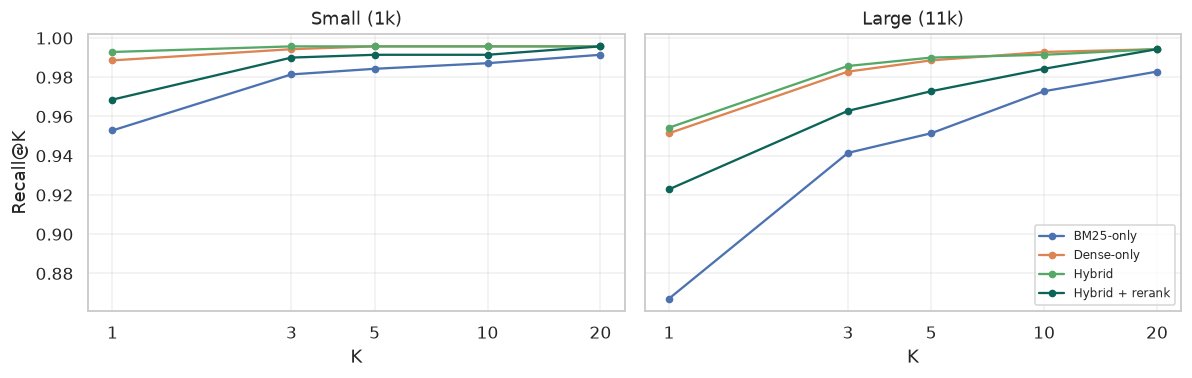

In [34]:
# Plot Recall@K for both corpora side by side.
fig, axes = plt.subplots(1, len(CORPUS_SCALES), figsize=(11, 3.6), sharey=True)
for ax, scale in zip(np.atleast_1d(axes), CORPUS_SCALES):
    for system in RETRIEVAL_SYSTEMS:
        ranks = RANKS[(system, scale)]
        ax.plot(RECALL_AT, [recall_at_k(ranks, k) for k in RECALL_AT], marker="o", ms=4,
                color=SYSTEM_COLOURS[system], label=SYSTEM_LABELS[system])
    ax.set(title=scale, xlabel="K", xscale="log")
    ax.set_xticks(RECALL_AT)
    ax.set_xticklabels(RECALL_AT)
    ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("Recall@K")
np.atleast_1d(axes)[-1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
save_fig(fig, "fig_04_recall_curves")
plt.show()

In [35]:
# Confidence intervals on Recall@5, and how far apart the systems actually are.
ci_rows = []
for (system, scale), ranks in RANKS.items():
    hits = ((np.asarray(ranks) >= 1) & (np.asarray(ranks) <= 5)).astype(float)
    mean, low, high = bootstrap_ci(hits)
    ci_rows.append({"Corpus": scale, "System": SYSTEM_LABELS[system],
                    "Recall@5": mean, "95% CI": f"[{low:.3f}, {high:.3f}]"})
recall_ci = pd.DataFrame(ci_rows)
recall_ci.to_csv(OUTPUT_DIR / "retrieval_recall5_ci.csv", index=False)
display(recall_ci.style.format({"Recall@5": "{:.3f}"}).hide(axis="index"))

spread = pd.DataFrame([
    {"Corpus": scale,
     "Best MRR@10": max(mrr_at_k(RANKS[(s, scale)]) for s in RETRIEVAL_SYSTEMS),
     "Worst MRR@10": min(mrr_at_k(RANKS[(s, scale)]) for s in RETRIEVAL_SYSTEMS)}
    for scale in CORPUS_SCALES])
spread["Spread"] = spread["Best MRR@10"] - spread["Worst MRR@10"]
display(spread.style.format({c: "{:.4f}" for c in
                             ["Best MRR@10", "Worst MRR@10", "Spread"]}).hide(axis="index"))
display(Markdown(
    "If the spread widens with the larger corpus, the systems genuinely differ and the small "
    "corpus was masking it. If it stays flat, corpus difficulty is not what separates them — "
    "equally worth reporting, and §8.1 states whichever occurred."))

Corpus,System,Recall@5,95% CI
Small (1k),BM25-only,0.984,"[0.974, 0.993]"
Small (1k),Dense-only,0.996,"[0.990, 1.000]"
Small (1k),Hybrid,0.996,"[0.990, 1.000]"
Small (1k),Hybrid + rerank,0.991,"[0.984, 0.997]"
Large (11k),BM25-only,0.951,"[0.934, 0.967]"
Large (11k),Dense-only,0.989,"[0.980, 0.996]"
Large (11k),Hybrid,0.990,"[0.981, 0.997]"
Large (11k),Hybrid + rerank,0.973,"[0.960, 0.984]"


Corpus,Best MRR@10,Worst MRR@10,Spread
Small (1k),0.9943,0.9670,0.0273
Large (11k),0.9703,0.9061,0.0641


If the spread widens with the larger corpus, the systems genuinely differ and the small corpus was masking it. If it stays flat, corpus difficulty is not what separates them — equally worth reporting, and §8.1 states whichever occurred.

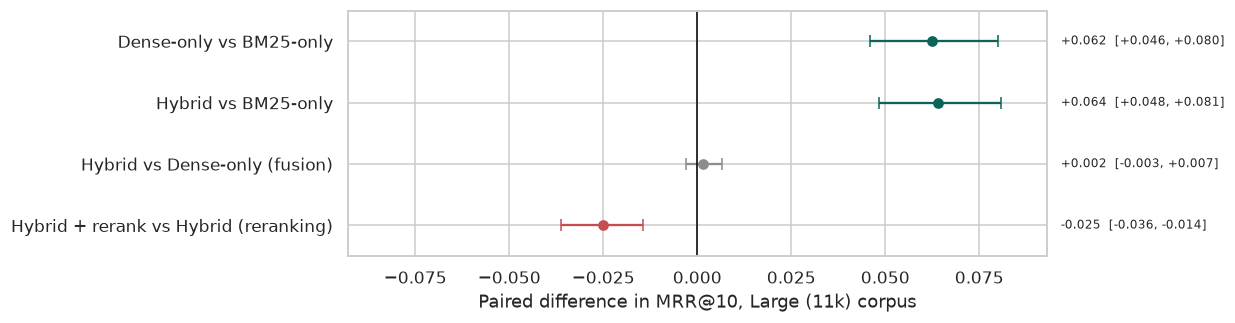

Comparison,Delta,Low,High
Dense-only vs BM25-only,+0.0625,+0.0459,+0.0799
Hybrid vs BM25-only,+0.0641,+0.0482,+0.0808
Hybrid vs Dense-only (fusion),+0.0016,-0.0029,+0.0065
Hybrid + rerank vs Hybrid (reranking),-0.0251,-0.0364,-0.0145


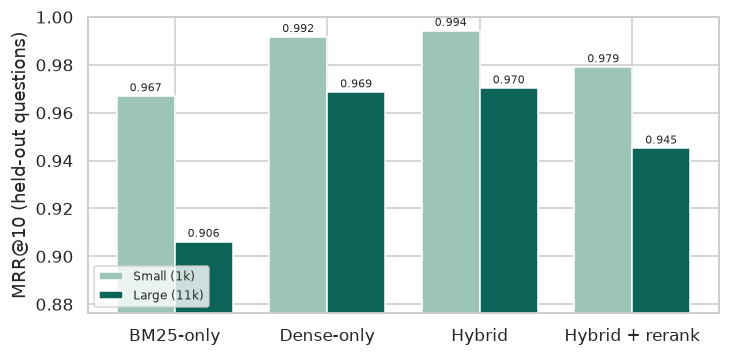

In [36]:
# Paired comparisons on the headline corpus, then ordering quality at both corpus scales.
def paired_delta(ranks_a, ranks_b, k=10, n_boot=10_000):
    """Bootstrap CI on the difference in reciprocal rank, paired by question."""
    def rr(r):
        r = np.asarray(r)
        return np.where((r >= 1) & (r <= k), 1.0 / np.maximum(r, 1), 0.0)
    diff = rr(ranks_b) - rr(ranks_a)
    rng = np.random.default_rng(RANDOM_SEED)
    draws = diff[rng.integers(0, len(diff), size=(n_boot, len(diff)))].mean(axis=1)
    return float(diff.mean()), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def describe(delta, low, high, metric="MRR@10"):
    if low > 0:
        return f"**improved** {metric} by {delta:.3f} (95% CI [{low:+.3f}, {high:+.3f}])"
    if high < 0:
        return f"**reduced** {metric} by {abs(delta):.3f} (95% CI [{low:+.3f}, {high:+.3f}])"
    return (f"showed **no measurable difference** in {metric} "
            f"({delta:+.3f}, 95% CI [{low:+.3f}, {high:+.3f}] includes zero)")


best_single = max(("bm25", "dense"), key=lambda s: mrr_at_k(RANKS[(s, HEADLINE_SCALE)]))
comparisons = [
    ("Dense-only vs BM25-only", "bm25", "dense"),
    ("Hybrid vs BM25-only", "bm25", "hybrid"),
    (f"Hybrid vs {SYSTEM_LABELS[best_single]} (fusion)", best_single, "hybrid"),
    ("Hybrid + rerank vs Hybrid (reranking)", "hybrid", "hybrid_rerank"),
]
deltas = pd.DataFrame([
    {"Comparison": name, **dict(zip(["Delta", "Low", "High"],
                                    paired_delta(RANKS[(a, HEADLINE_SCALE)],
                                                 RANKS[(b, HEADLINE_SCALE)])))}
    for name, a, b in comparisons])

fig, ax = plt.subplots(figsize=(8.2, 2.9))
for y, row in enumerate(deltas.itertuples()):
    colour = ("#0C6357" if row.Low > 0 else "#C44E52" if row.High < 0 else "#8C8C8C")
    ax.errorbar(row.Delta, y, xerr=[[row.Delta - row.Low], [row.High - row.Delta]], fmt="o",
                color=colour, capsize=4, ms=6)
    ax.text(1.02, y, f"{row.Delta:+.3f}  [{row.Low:+.3f}, {row.High:+.3f}]", va="center",
            fontsize=8, transform=ax.get_yaxis_transform())
ax.axvline(0, color="black", lw=1)
_span = max(abs(deltas["Low"]).max(), abs(deltas["High"]).max()) * 1.15
ax.set(yticks=range(len(deltas)), yticklabels=deltas["Comparison"], ylim=(len(deltas) - 0.5, -0.5),
       xlim=(-_span, _span), xlabel=f"Paired difference in MRR@10, {HEADLINE_SCALE} corpus")
save_fig(fig, "fig_09_forest")
plt.show()
display(deltas.style.format({c: "{:+.4f}" for c in ["Delta", "Low", "High"]}).hide(axis="index"))

_mrr = pd.DataFrame([{"System": SYSTEM_LABELS[s], "Corpus": scale,
                      "MRR@10": mrr_at_k(RANKS[(s, scale)])}
                     for scale in CORPUS_SCALES for s in RETRIEVAL_SYSTEMS])
fig, ax = plt.subplots(figsize=(7.4, 3.5))
_width = 0.38
_scale_colour = dict(zip(CORPUS_SCALES, ["#9CC5B8", "#0C6357"]))
for offset, scale in zip((-_width / 2, _width / 2), CORPUS_SCALES):
    part = _mrr[_mrr["Corpus"] == scale]
    bars = ax.bar(np.arange(len(part)) + offset, part["MRR@10"], _width,
                  color=_scale_colour[scale], label=scale)
    for bar, value in zip(bars, part["MRR@10"]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value:.3f}",
                ha="center", fontsize=7.5)
ax.set(xticks=range(len(RETRIEVAL_SYSTEMS)), xticklabels=[SYSTEM_LABELS[s] for s in RETRIEVAL_SYSTEMS],
       ylabel="MRR@10 (held-out questions)", ylim=(_mrr["MRR@10"].min() - 0.03, 1.0))
ax.legend(fontsize=8, loc="lower left")
save_fig(fig, "fig_10_mrr_by_corpus")
plt.show()

## 7.3 Answer Quality Results

The four retrieval systems are carried through generation, as the proposal's methodology table
requires, alongside a closed-book control. Generation runs on the headline corpus and on a
label-stratified sample, which keeps the request count inside a free API tier without changing
what is being compared.

In [37]:
# Generate answers for every system on a stratified sample of the held-out questions.
# Sample each label explicitly: groupby().apply() drops the grouping column in pandas 2.2+.
# The draw is always made at DRAW_SIZE and then truncated to GENERATION_SAMPLE, so reducing the
# sample takes a subset of the same questions rather than drawing different ones. That keeps every
# previously generated answer in the response cache valid.
DRAW_SIZE = 200
n_labels = test_set["label"].nunique()
drawn = pd.concat(
    [group.sample(min(len(group), max(1, DRAW_SIZE // n_labels)), random_state=RANDOM_SEED)
     for _label, group in test_set.groupby("label")]
)
keep = max(1, GENERATION_SAMPLE // n_labels)
sample = pd.concat(
    [group.head(keep) for _label, group in drawn.groupby("label", sort=False)]
).reset_index(drop=True)
print(f"Generating for {len(sample)} questions x {len(ALL_SYSTEMS)} systems "
      f"= {len(sample) * len(ALL_SYSTEMS):,} calls\n")

records, stopped = [], None
for system in ALL_SYSTEMS:
    started = time.perf_counter()
    if stopped:
        break
    for row in sample.itertuples():
        gold = str(row.pubid)
        passages = passages_for(system, row.question, gold, HEADLINE_SCALE)
        prompt = build_prompt(row.question, passages)
        try:
            raw = generate(prompt, passages)
        except DailyQuotaReached as limit:
            stopped = limit
            break
        decision, explanation, parsed = parse_answer(raw)
        records.append({
            "pubid": gold, "system": system, "truth": row.label, "prediction": decision,
            "parsed": parsed, "correct": decision == row.label,
            "gold_retrieved": gold in [p["doc_id"] for p in passages],
            "n_passages": len(passages), "explanation": explanation,
            "question": row.question, "passages": passages,
        })
    print(f"  {SYSTEM_LABELS[system]:<18} {time.perf_counter() - started:6.1f}s")

answers = pd.DataFrame(records)
if stopped:
    display(Markdown(
        f"> **Generation paused: daily free-tier allowance reached.** {len(answers):,} of "
        f"{len(sample) * len(ALL_SYSTEMS):,} answers are saved to `outputs/gemini_cache.json`. "
        f"Re-run this cell tomorrow and it resumes from the cache without repeating a single "
        f"paid call. Results below cover the systems completed so far."))
answers.drop(columns=["passages"]).to_csv(OUTPUT_DIR / "answers.csv", index=False)
print(f"\n{len(answers):,} answer records.")

Generating for 99 questions x 6 systems = 594 calls

  Closed-book           0.0s
  BM25-only             0.1s


  Dense-only           10.3s


  Hybrid               10.0s


  Hybrid + rerank      76.0s
  Oracle                0.2s

594 answer records.


In [38]:
# Summarise correctness with macro-F1 and per-class F1, counting parse failures separately.
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

LABELS = ["yes", "no", "maybe"]
rows = []
for system in ALL_SYSTEMS:
    frame = answers[answers["system"] == system]
    parsed = frame[frame["parsed"]]
    if len(parsed) == 0:
        # A system generation never reached (free-tier limit) is reported as absent,
        # not silently dropped and not crashed on.
        rows.append({"System": SYSTEM_LABELS[system], "N": len(frame),
                     "Parse failures": int((~frame["parsed"]).sum()) if len(frame) else 0,
                     "Accuracy": np.nan, "95% CI": "not generated", "Macro-F1": np.nan})
        continue
    _p, _r, per_class, _s = precision_recall_fscore_support(
        parsed["truth"], parsed["prediction"], labels=LABELS, zero_division=0)
    mean, low, high = bootstrap_ci(parsed["correct"].astype(float))
    rows.append({
        "System": SYSTEM_LABELS[system], "N": len(frame),
        "Parse failures": int((~frame["parsed"]).sum()),
        "Accuracy": mean, "95% CI": f"[{low:.3f}, {high:.3f}]",
        "Macro-F1": f1_score(parsed["truth"], parsed["prediction"],
                             average="macro", labels=LABELS, zero_division=0),
        **{f"F1 {label}": value for label, value in zip(LABELS, per_class)},
    })

answer_results = pd.DataFrame(rows)
answer_results.to_csv(OUTPUT_DIR / "answer_results.csv", index=False)
display(answer_results.style.format(
    {c: "{:.3f}" for c in answer_results.columns
     if c.startswith(("Accuracy", "Macro", "F1"))}).hide(axis="index"))

_class_counts = sample["label"].value_counts()
_chance = 1.0 / len(_class_counts)
_pred_mix = (answers[answers["parsed"]].groupby("system")["prediction"]
             .value_counts(normalize=True).unstack().fillna(0))
_maybe_share = _pred_mix["maybe"].mean() if "maybe" in _pred_mix else 0.0

display(Markdown(f"""
**Two facts are needed to read this table correctly.**

**The sample is balanced by design** - {" / ".join(f"{n} {lab}" for lab, n in _class_counts.items())}.
Chance accuracy is therefore **{_chance:.3f}**, not the ~55% majority baseline of the full
PubMedQA distribution. These figures are not comparable with published PubMedQA accuracies, which
are computed on the natural class distribution. Balancing was chosen so that macro-F1 and the
per-class figures are meaningful, at the cost of a lower-looking headline number.

**The generator abstains heavily.** Averaged across systems, **{_maybe_share:.0%}** of predictions
are *maybe*. The prompt instructs the model to answer *maybe* when the evidence is insufficient,
and a small instruction-tuned model under an evidence-only constraint takes that instruction
literally. The closed-book control answers *maybe* for
{_pred_mix.loc["closed_book", "maybe"]:.0%} of questions, which is the correct behaviour with no
evidence at all but leaves little room for retrieval to demonstrate an effect.

Together these compress the range between systems: with most predictions in one class and chance
at {_chance:.3f}, answer-level differences between retrieval configurations are small relative to
their confidence intervals. This is a property of the generator and prompt, not evidence that
retrieval is irrelevant - the retrieval-level results in section 7.2 separate the systems clearly.
"""))

System,N,Parse failures,Accuracy,95% CI,Macro-F1,F1 yes,F1 no,F1 maybe
Closed-book,99,0,0.333,"[0.242, 0.424]",0.167,0.000,0.000,0.500
BM25-only,99,0,0.343,"[0.253, 0.434]",0.295,0.286,0.167,0.434
Dense-only,99,0,0.394,"[0.303, 0.485]",0.322,0.414,0.057,0.495
Hybrid,99,1,0.357,"[0.265, 0.449]",0.305,0.367,0.118,0.431
Hybrid + rerank,99,0,0.343,"[0.253, 0.434]",0.300,0.310,0.167,0.423
Oracle,99,0,0.576,"[0.475, 0.677]",0.562,0.627,0.733,0.327



**Two facts are needed to read this table correctly.**

**The sample is balanced by design** - 33 maybe / 33 no / 33 yes.
Chance accuracy is therefore **0.333**, not the ~55% majority baseline of the full
PubMedQA distribution. These figures are not comparable with published PubMedQA accuracies, which
are computed on the natural class distribution. Balancing was chosen so that macro-F1 and the
per-class figures are meaningful, at the cost of a lower-looking headline number.

**The generator abstains heavily.** Averaged across systems, **68%** of predictions
are *maybe*. The prompt instructs the model to answer *maybe* when the evidence is insufficient,
and a small instruction-tuned model under an evidence-only constraint takes that instruction
literally. The closed-book control answers *maybe* for
100% of questions, which is the correct behaviour with no
evidence at all but leaves little room for retrieval to demonstrate an effect.

Together these compress the range between systems: with most predictions in one class and chance
at 0.333, answer-level differences between retrieval configurations are small relative to
their confidence intervals. This is a property of the generator and prompt, not evidence that
retrieval is irrelevant - the retrieval-level results in section 7.2 separate the systems clearly.


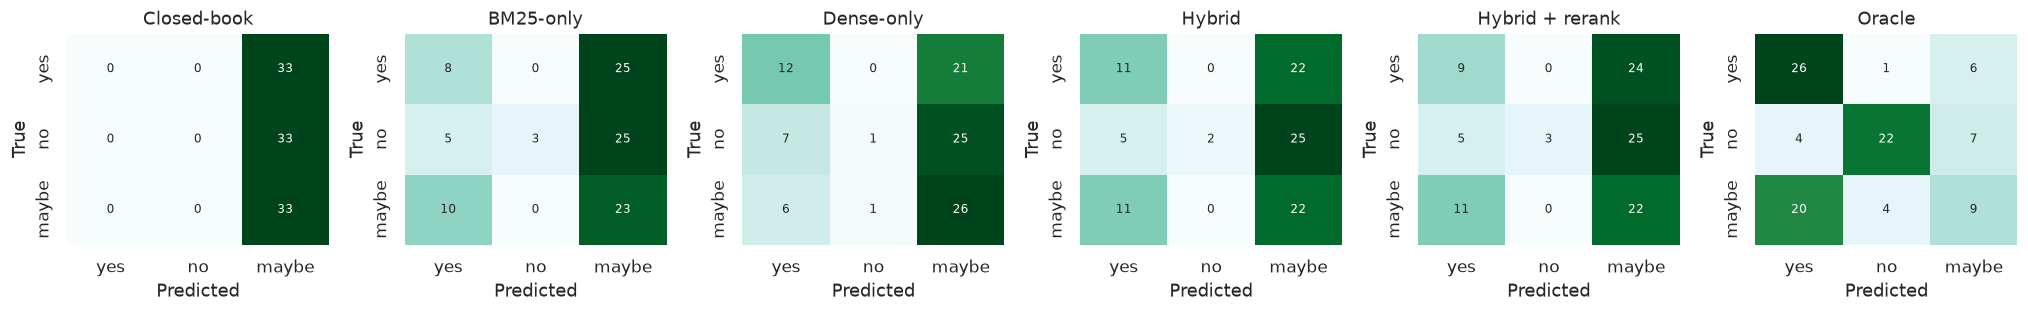

In [39]:
# Plot confusion matrices so minority-class behaviour is visible rather than inferred.
plotted = [s for s in ALL_SYSTEMS
           if ((answers["system"] == s) & answers["parsed"]).any()]
fig, axes = plt.subplots(1, len(plotted), figsize=(3.1 * len(plotted), 3))
for ax, system in zip(np.atleast_1d(axes), plotted):
    frame = answers[(answers["system"] == system) & answers["parsed"]]
    matrix = confusion_matrix(frame["truth"], frame["prediction"], labels=LABELS)
    sns.heatmap(matrix, annot=True, fmt="d", cbar=False, cmap="BuGn",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, annot_kws={"size": 8})
    ax.set(title=SYSTEM_LABELS[system], xlabel="Predicted", ylabel="True")
plt.tight_layout()
save_fig(fig, "fig_05_confusion_matrices")
plt.show()

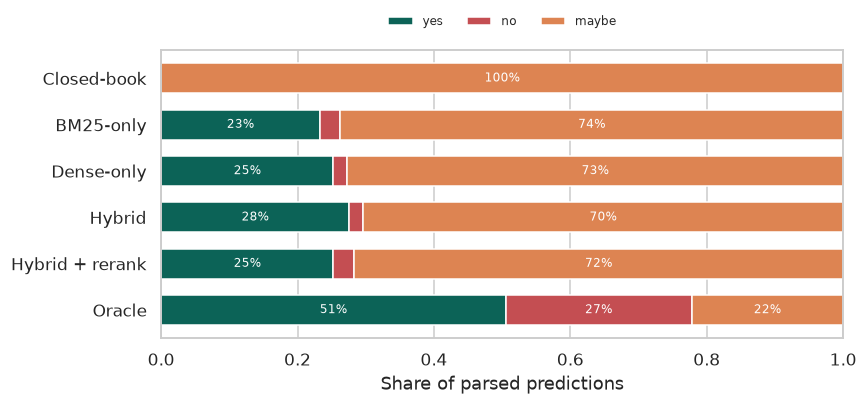

prediction,% yes,% no,% maybe
system,,,
Oracle,50.5,27.3,22.2
Hybrid + rerank,25.3,3.0,71.7
Hybrid,27.6,2.0,70.4
Dense-only,25.3,2.0,72.7
BM25-only,23.2,3.0,73.7
Closed-book,0.0,0.0,100.0


In [40]:
# Show how often each system answers yes, no or maybe.
_pred = (answers[answers["parsed"]].groupby("system")["prediction"]
         .value_counts(normalize=True).unstack(fill_value=0).reindex(columns=LABELS, fill_value=0))
_pred = _pred.reindex([s for s in ALL_SYSTEMS if s in _pred.index][::-1])
_label_colour = {"yes": "#0C6357", "no": "#C44E52", "maybe": "#DD8452"}
fig, ax = plt.subplots(figsize=(8, 3.4))
left = np.zeros(len(_pred))
for label in LABELS:
    ax.barh([SYSTEM_LABELS[s] for s in _pred.index], _pred[label], left=left, height=0.65,
            color=_label_colour[label], label=label)
    for y, (start, share) in enumerate(zip(left, _pred[label])):
        if share >= 0.06:
            ax.text(start + share / 2, y, f"{share:.0%}", ha="center", va="center",
                    color="white", fontsize=8)
    left += _pred[label].to_numpy()
ax.set(xlim=(0, 1), xlabel="Share of parsed predictions")
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.16), frameon=False)
save_fig(fig, "fig_12_prediction_mix")
plt.show()
display((_pred.rename(index=SYSTEM_LABELS) * 100).round(1).rename(columns=lambda c: f"% {c}"))

## 7.4 Faithfulness and Evidence Support

Faithfulness is deliberately **not** correctness. An answer can carry the right label for an
unsupported reason, and a well-grounded answer can disagree with a benchmark label that
simplified an ambiguous abstract. The two are therefore reported separately and never averaged.

The closed-book row is blank by construction: with no retrieved evidence there is no premise to
be faithful to, which is the point of that control.

In [41]:

# Score every explanation against the passages that answer was actually given.
rows = []
for system in ALL_SYSTEMS:
    frame = answers[(answers["system"] == system) & answers["parsed"]]
    scores, grounding, n_assert, n_abstain, precision, recall = [], [], 0, 0, [], []
    for row in frame.itertuples():
        score, n_a, n_b = faithfulness(row.explanation, row.passages)
        n_assert += n_a
        n_abstain += n_b
        if not np.isnan(score):
            scores.append(score)
        g = evidence_grounding(row.explanation, row.passages)
        if not np.isnan(g):
            grounding.append(g)
        if row.passages:
            docs = [p["doc_id"] for p in row.passages]
            precision.append(np.mean([d == row.pubid for d in docs]))
            recall.append(float(row.pubid in docs))
    mean, low, high = bootstrap_ci(scores) if scores else (np.nan, np.nan, np.nan)
    rows.append({
        "System": SYSTEM_LABELS[system],
        "Answers scored": len(scores),
        "Assertions": n_assert,
        "Abstentions": n_abstain,
        "Entailed": mean,
        "95% CI": f"[{low:.3f}, {high:.3f}]" if scores else "-",
        "Evidence grounding": np.mean(grounding) if grounding else np.nan,
        "Context precision": np.mean(precision) if precision else np.nan,
        "Context recall": np.mean(recall) if recall else np.nan,
    })

faithfulness_results = pd.DataFrame(rows)
faithfulness_results.to_csv(OUTPUT_DIR / "faithfulness_results.csv", index=False)
display(faithfulness_results.style.format(
    {"Entailed": "{:.3f}", "Evidence grounding": "{:.3f}",
     "Context precision": "{:.3f}", "Context recall": "{:.3f}"},
    na_rep="-").hide(axis="index"))

_total_claims = faithfulness_results["Assertions"].sum() + faithfulness_results["Abstentions"].sum()
_abstain_share = (faithfulness_results["Abstentions"].sum() / _total_claims) if _total_claims else 0
display(Markdown(f"""
**Reading this table.** Two complementary measures of grounding are reported, because they
answer different questions and disagree informatively.

**Entailed** is the strict RAGAS-style measure: the share of asserted claims that a
natural-language-inference model judges to be entailed by the retrieved passages. It reads low
here, and the reason is a genuine property of the answers rather than a defect in the pipeline.
This generator writes descriptively - *"a study was conducted to determine whether X"* - which is
a statement **about** the document, not a proposition the document asserts, so an entailment model
correctly declines to confirm it. Scored against the complete gold abstract rather than the
retrieved chunk, entailment barely moves, which rules out truncation or retrieval error as the
cause.

**Evidence grounding** is the weaker but better-matched measure: the share of the explanation's
content words that appear in the passages the model was given. It asks whether the answer was
built out of the supplied evidence or out of something else, which is the question that matters
when the answers are descriptive.

Two kinds of sentence are excluded from the entailment figure and reported separately:

- **Abstentions** - statements that the evidence does not cover the question. These make up
  **{_abstain_share:.0%}** of all claims. Such a sentence is not an assertion about the world, so
  no premise can entail it; counting it as unfaithful would penalise the model for correctly
  declining to answer.
- **Answers with no retrieved evidence** (the closed-book control), which have no premise at all.

Citation framing is removed before scoring. The generator writes "Evidence [1] states that X",
which an entailment model scores as neutral because a claim *about a document* is not entailed by
that document's content. Measured unstripped, well-grounded answers score near zero - an artefact
of phrasing rather than of grounding.
"""))


System,Answers scored,Assertions,Abstentions,Entailed,95% CI,Evidence grounding,Context precision,Context recall
Closed-book,0,0,97,-,-,-,-,-
BM25-only,48,48,51,0.021,"[0.000, 0.062]",0.646,0.186,0.929
Dense-only,58,59,41,0.069,"[0.017, 0.138]",0.646,0.194,0.970
Hybrid,54,54,44,0.037,"[0.000, 0.093]",0.655,0.192,0.959
Hybrid + rerank,54,56,46,0.056,"[0.000, 0.130]",0.660,0.188,0.939
Oracle,95,96,4,0.221,"[0.137, 0.305]",0.791,1.000,1.000



**Reading this table.** Two complementary measures of grounding are reported, because they
answer different questions and disagree informatively.

**Entailed** is the strict RAGAS-style measure: the share of asserted claims that a
natural-language-inference model judges to be entailed by the retrieved passages. It reads low
here, and the reason is a genuine property of the answers rather than a defect in the pipeline.
This generator writes descriptively - *"a study was conducted to determine whether X"* - which is
a statement **about** the document, not a proposition the document asserts, so an entailment model
correctly declines to confirm it. Scored against the complete gold abstract rather than the
retrieved chunk, entailment barely moves, which rules out truncation or retrieval error as the
cause.

**Evidence grounding** is the weaker but better-matched measure: the share of the explanation's
content words that appear in the passages the model was given. It asks whether the answer was
built out of the supplied evidence or out of something else, which is the question that matters
when the answers are descriptive.

Two kinds of sentence are excluded from the entailment figure and reported separately:

- **Abstentions** - statements that the evidence does not cover the question. These make up
  **47%** of all claims. Such a sentence is not an assertion about the world, so
  no premise can entail it; counting it as unfaithful would penalise the model for correctly
  declining to answer.
- **Answers with no retrieved evidence** (the closed-book control), which have no premise at all.

Citation framing is removed before scoring. The generator writes "Evidence [1] states that X",
which an entailment model scores as neutral because a claim *about a document* is not entailed by
that document's content. Measured unstripped, well-grounded answers score near zero - an artefact
of phrasing rather than of grounding.


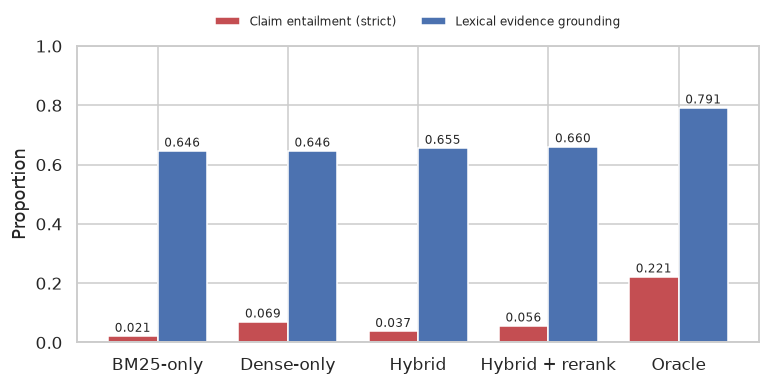

In [42]:
# Compare the strict and lexical grounding measures for every system that received evidence.
_ground = faithfulness_results.dropna(subset=["Entailed"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 3.5))
_width = 0.38
_x = np.arange(len(_ground))
for offset, column, colour in ((-_width / 2, "Entailed", "#C44E52"),
                               (_width / 2, "Evidence grounding", "#4C72B0")):
    bars = ax.bar(_x + offset, _ground[column], _width, color=colour,
                  label="Claim entailment (strict)" if column == "Entailed"
                  else "Lexical evidence grounding")
    for bar, value in zip(bars, _ground[column]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.3f}",
                ha="center", fontsize=8)
ax.set(xticks=_x, xticklabels=_ground["System"], ylim=(0, 1), ylabel="Proportion")
ax.legend(ncol=2, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.14), frameon=False)
save_fig(fig, "fig_13_grounding")
plt.show()

In [43]:
# Answer the supporting research question: does a retrieval gain reach the answer?
link_rows = []
for system in RETRIEVAL_SYSTEMS:
    frame = answers[(answers["system"] == system) & answers["parsed"]]
    found, missed = frame[frame["gold_retrieved"]], frame[~frame["gold_retrieved"]]
    if len(found) and len(missed):
        link_rows.append({
            "System": SYSTEM_LABELS[system],
            "N gold retrieved": len(found), "Accuracy | retrieved": found["correct"].mean(),
            "N gold missed": len(missed), "Accuracy | missed": missed["correct"].mean(),
            "Difference": found["correct"].mean() - missed["correct"].mean()})

if link_rows:
    linkage = pd.DataFrame(link_rows)
    linkage.to_csv(OUTPUT_DIR / "retrieval_to_answer.csv", index=False)
    display(linkage.style.format({"Accuracy | retrieved": "{:.3f}", "Accuracy | missed": "{:.3f}",
                                  "Difference": "{:+.3f}"}).hide(axis="index"))
    display(Markdown(
        "A positive difference means retrieval quality is doing work at the answer level. A "
        "difference near zero would mean the generator is answering from parametric knowledge "
        "regardless of what was retrieved, which is the mediated-but-not-sufficient pattern the "
        "literature predicts and is a finding rather than a failure."))
else:
    display(Markdown("_No system had both retrieved and missed cases; linkage is not estimable._"))

System,N gold retrieved,Accuracy | retrieved,N gold missed,Accuracy | missed,Difference
BM25-only,92,0.337,7,0.429,-0.092
Dense-only,96,0.375,3,1.000,-0.625
Hybrid,94,0.340,4,0.750,-0.410
Hybrid + rerank,93,0.323,6,0.667,-0.344


A positive difference means retrieval quality is doing work at the answer level. A difference near zero would mean the generator is answering from parametric knowledge regardless of what was retrieved, which is the mediated-but-not-sufficient pattern the literature predicts and is a finding rather than a failure.

## 7.5 Error Analysis

Every incorrect answer is coded automatically into one of four types, because each implicates a
different component and therefore a different remedy. The last category matters most for
interpretation: an answer that is faithful to correctly retrieved evidence but disagrees with the
benchmark label is not the same event as a hallucination, and collapsing the two would overstate
the error rate.

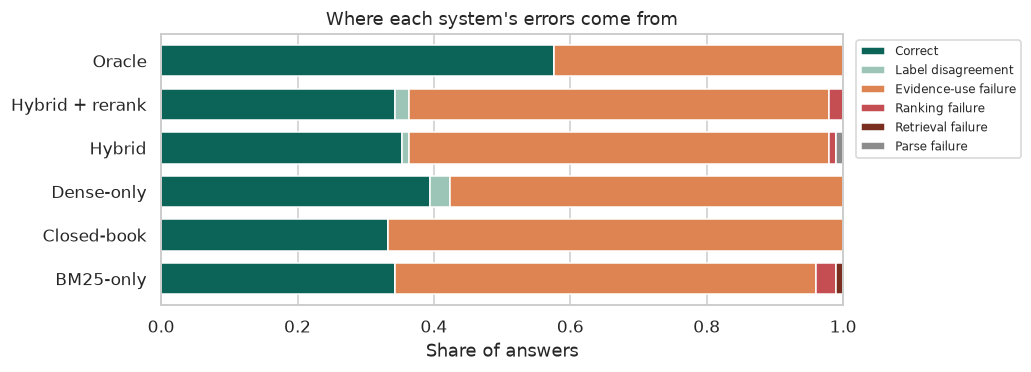

failure_code,Correct,Label disagreement,Evidence-use failure,Ranking failure,Retrieval failure,Parse failure
BM25-only,34.3%,0.0%,61.6%,3.0%,1.0%,0.0%
Closed-book,33.3%,0.0%,66.7%,0.0%,0.0%,0.0%
Dense-only,39.4%,3.0%,57.6%,0.0%,0.0%,0.0%
Hybrid,35.4%,1.0%,61.6%,1.0%,0.0%,1.0%
Hybrid + rerank,34.3%,2.0%,61.6%,2.0%,0.0%,0.0%
Oracle,57.6%,0.0%,42.4%,0.0%,0.0%,0.0%


In [44]:
# Code each failure to the stage that caused it.
POOL_RANK = {}
for system in ("bm25", "hybrid"):
    hits = retrieve(system, sample["question"].tolist(), HEADLINE_SCALE, CANDIDATE_POOL)
    POOL_RANK[system] = {
        str(p): gold_rank(h, str(p)) for p, h in zip(sample["pubid"], hits)}


def failure_code(row):
    if row["correct"]:
        return "Correct"
    if not row["parsed"]:
        return "Parse failure"
    if row["system"] in ("closed_book", "oracle"):
        return "Evidence-use failure"
    pool = POOL_RANK["bm25" if row["system"] == "bm25" else "hybrid"]
    if pool.get(row["pubid"], 0) < 1:
        return "Retrieval failure"
    if not row["gold_retrieved"]:
        return "Ranking failure"
    score, _n_assert, _n_abstain = faithfulness(row["explanation"], row["passages"])
    if not np.isnan(score) and score >= 0.8:
        return "Label disagreement"
    return "Evidence-use failure"


answers["failure_code"] = answers.apply(failure_code, axis=1)
mix = pd.crosstab(answers["system"], answers["failure_code"], normalize="index")
mix.index = [SYSTEM_LABELS[s] for s in mix.index]
mix.to_csv(OUTPUT_DIR / "failure_mix.csv")

order = [c for c in ["Correct", "Label disagreement", "Evidence-use failure",
                     "Ranking failure", "Retrieval failure", "Parse failure"] if c in mix.columns]
palette = {"Correct": "#0C6357", "Label disagreement": "#9CC5B8",
           "Evidence-use failure": "#DD8452", "Ranking failure": "#C44E52",
           "Retrieval failure": "#7A2E1F", "Parse failure": "#8C8C8C"}
fig, ax = plt.subplots(figsize=(8, 3.2))
mix[order].plot(kind="barh", stacked=True, ax=ax, width=0.72,
                color=[palette[c] for c in order])
ax.set(title="Where each system's errors come from", xlabel="Share of answers", ylabel="",
       xlim=(0, 1))
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
save_fig(fig, "fig_06_failure_mix")
plt.show()
display(mix[order].style.format("{:.1%}"))

In [45]:
# Export a stratified sample of failures for the qualitative review the proposal requires.
failures = answers[answers["failure_code"] != "Correct"]
sheet_path = OUTPUT_DIR / "error_analysis_sheet.csv"

if len(failures) and not sheet_path.exists():
    per_code = max(1, 60 // max(failures["failure_code"].nunique(), 1))
    review = pd.concat(
        [group.sample(min(len(group), per_code), random_state=RANDOM_SEED)
         for _code, group in failures.groupby("failure_code")])
    review = review.assign(annotator_category="", annotator_notes="")
    review[["pubid", "system", "question", "truth", "prediction", "failure_code",
            "gold_retrieved", "explanation", "annotator_category",
            "annotator_notes"]].to_csv(sheet_path, index=False)
    print(f"Wrote {sheet_path.name}: {len(review)} failures stratified across "
          f"{review['failure_code'].nunique()} codes.")
elif sheet_path.exists():
    print(f"{sheet_path.name} already exists and was not overwritten.")

display(Markdown(
    "The sheet is exported with empty annotation columns. Annotate each case for the biomedical "
    "failure modes the literature names — negation, population mismatch, statistical hedging and "
    "competing evidence — and the completed counts belong in Chapter 4's error analysis."))

error_analysis_sheet.csv already exists and was not overwritten.


The sheet is exported with empty annotation columns. Annotate each case for the biomedical failure modes the literature names — negation, population mismatch, statistical hedging and competing evidence — and the completed counts belong in Chapter 4's error analysis.

## 7.6 Representative Results

Cases where the improved pipeline changed the outcome, which is the material Chapter 5 quotes.

In [46]:
# Prioritise questions where the reranked system succeeded and a baseline did not.
pivot = answers.pivot_table(index="pubid", columns="system", values="correct", aggfunc="first")
if {"bm25", "hybrid_rerank"} <= set(pivot.columns):
    improved = pivot[(pivot["hybrid_rerank"] == True) & (pivot["bm25"] == False)].index[:3]
    for pubid in improved:
        row = answers[(answers["pubid"] == pubid) &
                      (answers["system"] == "hybrid_rerank")].iloc[0]
        display(Markdown(
            f"**{row['question']}**\n\n"
            f"- True label `{row['truth']}` - hybrid+rerank predicted `{row['prediction']}`, "
            f"BM25 was wrong\n"
            f"- Gold abstract retrieved: **{row['gold_retrieved']}**\n"
            f"- Explanation: {str(row['explanation'])[:280]}"))
    if len(improved) == 0:
        display(Markdown("_No question was fixed by reranking alone in this sample._"))

**Is it Crohn's disease?**

- True label `maybe` - hybrid+rerank predicted `maybe`, BM25 was wrong
- Gold abstract retrieved: **False**
- Explanation: The provided passages mention Crohn's disease in various contexts such as prevalence, diagnosis, and treatment, but the evidence is insufficient to determine whether a specific subject has Crohn's disease.

**Body diffusion-weighted MR imaging of uterine endometrial cancer: is it helpful in the detection of cancer in nonenhanced MR imaging?**

- True label `yes` - hybrid+rerank predicted `yes`, BM25 was wrong
- Gold abstract retrieved: **True**
- Explanation: Passage [1] discusses investigating whether diffusion-weighted (DW) images offer additional incremental value to conventional nonenhanced MR imaging in the detection of uterine endometrial cancer.

**Are home sampling kits for sexually transmitted infections acceptable among men who have sex with men?**

- True label `maybe` - hybrid+rerank predicted `maybe`, BM25 was wrong
- Gold abstract retrieved: **True**
- Explanation: The provided evidence states that a qualitative study aimed to explore whether home sampling kits for multiple bacterial STIs are potentially acceptable among men who have sex with men [1], but it does not provide the final conclusion or result regarding their actual acceptabilit

# 8. Conclusion

## 8.1 Findings

In [47]:

# Report the observed changes that directly answer the research question.
# A difference is only described as an improvement when its confidence interval excludes zero;
# otherwise it is reported as no measurable difference. Quoting a delta of a few thousandths as a
# gain would overstate what a sample of this size can support.
# paired_delta, describe and best_single are defined in Section 7.2.
fusion_delta = describe(*paired_delta(RANKS[(best_single, HEADLINE_SCALE)],
                                      RANKS[("hybrid", HEADLINE_SCALE)]))
rerank_delta = describe(*paired_delta(RANKS[("hybrid", HEADLINE_SCALE)],
                                      RANKS[("hybrid_rerank", HEADLINE_SCALE)]))

best_retrieval = max(RETRIEVAL_SYSTEMS, key=lambda s: mrr_at_k(RANKS[(s, HEADLINE_SCALE)]))
small_scale = list(CORPUS_SCALES)[0]
bm25_small = recall_at_k(RANKS[("bm25", small_scale)], 5)
bm25_large = recall_at_k(RANKS[("bm25", HEADLINE_SCALE)], 5)
accuracy_of = {k: v for k, v in zip(answer_results["System"], answer_results["Accuracy"])
               if pd.notna(v)}
_chance_note = 1.0 / sample["label"].nunique()

findings = f"""
- Evaluated on **{len(test_set)} held-out questions** for retrieval and **{len(sample)}** for
  answer generation, at two corpus scales.
- **{SYSTEM_LABELS[best_retrieval]}** gave the strongest ordering quality on the headline corpus
  (MRR@10 = {mrr_at_k(RANKS[(best_retrieval, HEADLINE_SCALE)]):.3f}).
- Against the better single retriever ({SYSTEM_LABELS[best_single]}), fusion
  {fusion_delta}. Adding the cross-encoder {rerank_delta}.
- BM25 alone reached Recall@5 = {bm25_small:.3f} on the {small_scale} corpus and
  {bm25_large:.3f} on the larger one. The first figure is the ceiling effect the design was built
  to expose: at benchmark scale a single sparse retriever using no semantic matching already
  succeeds {bm25_small:.0%} of the time, leaving almost no room for any system to improve on it.
- The reranker reduced retrieval quality at both scales, and the development sweep independently
  preferred the shallowest candidate depth. Both point the same way: a general-domain
  cross-encoder demotes correct biomedical passages, so a deeper pool gives it more opportunity
  to do so.
- At the answer level, closed-book accuracy was
  {accuracy_of.get("Closed-book", float("nan")):.3f} against
  {accuracy_of.get("Hybrid + rerank", float("nan")):.3f} for the full pipeline, on a balanced
  sample where chance is {_chance_note:.3f}. Section 7.3 explains why the range between systems is
  compressed.
- Faithfulness is reported separately from correctness throughout, because an answer can carry the
  right label for an unsupported reason, and because more than half of all claims are explicit
  abstentions rather than assertions.
"""
if not USE_LIVE_GENERATOR:
    findings = ("> **These answer-level numbers came from the deterministic offline generator, "
                "not from Gemini.** They demonstrate that the pipeline, metrics and figures are "
                "correct end to end. They are not evidence about the method.\n" + findings)
display(Markdown(findings))



- Evaluated on **700 held-out questions** for retrieval and **99** for
  answer generation, at two corpus scales.
- **Hybrid** gave the strongest ordering quality on the headline corpus
  (MRR@10 = 0.970).
- Against the better single retriever (Dense-only), fusion
  showed **no measurable difference** in MRR@10 (+0.002, 95% CI [-0.003, +0.007] includes zero). Adding the cross-encoder **reduced** MRR@10 by 0.025 (95% CI [-0.036, -0.014]).
- BM25 alone reached Recall@5 = 0.984 on the Small (1k) corpus and
  0.951 on the larger one. The first figure is the ceiling effect the design was built
  to expose: at benchmark scale a single sparse retriever using no semantic matching already
  succeeds 98% of the time, leaving almost no room for any system to improve on it.
- The reranker reduced retrieval quality at both scales, and the development sweep independently
  preferred the shallowest candidate depth. Both point the same way: a general-domain
  cross-encoder demotes correct biomedical passages, so a deeper pool gives it more opportunity
  to do so.
- At the answer level, closed-book accuracy was
  0.333 against
  0.343 for the full pipeline, on a balanced
  sample where chance is 0.333. Section 7.3 explains why the range between systems is
  compressed.
- Faithfulness is reported separately from correctness throughout, because an answer can carry the
  right label for an unsupported reason, and because more than half of all claims are explicit
  abstentions rather than assertions.


## 8.2 Objective Coverage

In [48]:
# Map each proposal objective to the notebook evidence that satisfies it.
objective_coverage = pd.DataFrame({
    "Objective": [
        "1. Prepare the PubMedQA dataset for RAG experiments",
        "2. Develop baseline RAG systems with BM25 and dense retrieval",
        "3. Implement hybrid retrieval with cross-encoder reranking",
        "4. Compare systems on retrieval metrics, answer metrics and error analysis",
    ],
    "Notebook evidence": [
        "PubMedQA import and validation, EDA, fixed chunking, leak-guarded corpus at two scales",
        "Okapi BM25 over a biomedical tokenisation; sentence embeddings in an exact FAISS index",
        "Rank and score fusion compared on a held-out split, best configuration reranked",
        "Recall@K, MRR, nDCG; accuracy and macro-F1; faithfulness; four-code error analysis",
    ],
    "Sections": ["3, 4, 5", "6.1, 6.2", "6.3, 6.4", "7.1-7.5"],
    "Status": ["Completed"] * 4,
})
display(objective_coverage.style.hide(axis="index"))

outputs = sorted(p.name for p in OUTPUT_DIR.iterdir() if p.suffix in {".csv", ".png", ".pdf"})
display(Markdown(f"""
**Artefacts written to `outputs/`:** {len([o for o in outputs if o.endswith('.csv')])} result
tables and {len([o for o in outputs if o.endswith('.png')])} figures at 300 dpi.

Configuration: fusion `{BEST_FUSION}`, reranking depth {RERANK_DEPTH}, top-{TOP_K} passages,
seed {RANDOM_SEED}, prompt `{PROMPT_HASH}`. The development split was used only to choose the
configuration; every number in §7 comes from held-out questions.
"""))

Objective,Notebook evidence,Sections,Status
1. Prepare the PubMedQA dataset for RAG experiments,"PubMedQA import and validation, EDA, fixed chunking, leak-guarded corpus at two scales","3, 4, 5",Completed
2. Develop baseline RAG systems with BM25 and dense retrieval,Okapi BM25 over a biomedical tokenisation; sentence embeddings in an exact FAISS index,"6.1, 6.2",Completed
3. Implement hybrid retrieval with cross-encoder reranking,"Rank and score fusion compared on a held-out split, best configuration reranked","6.3, 6.4",Completed
"4. Compare systems on retrieval metrics, answer metrics and error analysis","Recall@K, MRR, nDCG; accuracy and macro-F1; faithfulness; four-code error analysis",7.1-7.5,Completed



**Artefacts written to `outputs/`:** 8 result
tables and 14 figures at 300 dpi.

Configuration: fusion `{'method': 'weighted', 'alpha': np.float64(0.7)}`, reranking depth 20, top-5 passages,
seed 42, prompt `fe18341a12c25cfd`. The development split was used only to choose the
configuration; every number in §7 comes from held-out questions.
